# ACA 2 · Dashboard analítico y EDA avanzado
## Abandono de clientes en telecomunicaciones (*Telco Customer Churn*)

**Asignatura:** Programación para Analítica de Datos e IA  
**Programa:** Especialización en Inteligencia Artificial · Corporación Unificada Nacional de Educación Superior (CUN)  
**Integrantes:** Bonny Darhyll Brayan Galindo Santos · Andrés Alberto López Herrera · Camilo José Rodríguez Ayubi  
**Docente:** Hamilton Rivera  
**Fecha:** septiembre de 2026

> **Enlaces del proyecto**
> - **Aplicación publicada (Streamlit Community Cloud):** https://aca2-telco-churn-cun.streamlit.app
> - **Repositorio del proyecto (GitHub):** https://github.com/bonnymusic77-web/aca2-dashboard-telco-churn
> - **Este notebook en Google Colab:** https://colab.research.google.com/github/bonnymusic77-web/aca2-dashboard-telco-churn/blob/main/ACA2_Dashboard_EDA_Telco_Churn.ipynb
> - **Video de sustentación:** *(pegar enlace de YouTube o Google Drive)*

**Contenido**
1. Objetivos y propuesta
2. Preparación del entorno
3. Limpieza y preprocesamiento
4. Análisis exploratorio avanzado
5. Lógica del análisis automático
6. Arquitectura y código del dashboard
7. Conclusiones
8. Referencias

## 1. Objetivos y propuesta

En el ACA 1 hicimos el primer análisis exploratorio de la base *Telco Customer Churn* (IBM), con 7.043 clientes de una empresa de telecomunicaciones y la marca de quiénes se retiraron en el último mes. En esta entrega retomamos el mismo dataset para profundizar el análisis con pruebas estadísticas y llevarlo a una aplicación web que cualquier persona del área comercial pueda usar sin escribir código.

**Pregunta de negocio:** ¿qué características de los clientes y de sus contratos se relacionan con el abandono, y en qué segmentos se concentra el ingreso que la empresa pierde?

**Objetivo general.** Construir un dashboard interactivo en Python que permita explorar el abandono de clientes y obtener hallazgos respaldados por evidencia estadística.

**Objetivos específicos**
1. Automatizar la limpieza y transformación del archivo crudo en un *pipeline* reutilizable que deje registro de cada paso.
2. Profundizar el EDA con pruebas de hipótesis, tamaños de efecto y análisis de correlación.
3. Desarrollar una aplicación en Streamlit con filtros dinámicos, gráficos interactivos y una sección de análisis automático.
4. Convertir los resultados en recomendaciones concretas de retención.

**Propuesta.** El código se divide en cuatro módulos. El notebook los genera con `%%writefile` y luego los importa, así el análisis de este documento y el dashboard publicado corren exactamente la misma lógica.

| Módulo | Responsabilidad |
|---|---|
| `procesamiento.py` | Carga, diagnóstico, limpieza y transformación de datos |
| `analisis.py` | Estadística descriptiva, pruebas de hipótesis y hallazgos automáticos |
| `graficos.py` | Figuras interactivas en Plotly para el dashboard |
| `app.py` | Interfaz web en Streamlit (filtros, pestañas e indicadores) |

## 2. Preparación del entorno

El notebook está pensado para Google Colab, aunque también corre en Jupyter local. Todas las librerías de análisis vienen instaladas en Colab; Streamlit solo se instala en la sección 6 para probar la aplicación.

In [1]:
import os
import shutil
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import Markdown, display

EN_COLAB = "google.colab" in sys.modules
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

print(f"Entorno: {'Google Colab' if EN_COLAB else 'Jupyter local'}")
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · NumPy {np.__version__} · "
      f"SciPy {scipy.__version__} · seaborn {sns.__version__}")

Entorno: Jupyter local
Python 3.11.15 · pandas 3.0.2 · NumPy 2.4.4 · SciPy 1.17.1 · seaborn 0.13.2


Creamos una carpeta `telco_dashboard/` con la misma estructura del repositorio que se publica en Streamlit Community Cloud. El CSV se descarga del repositorio público de IBM, que contiene el mismo archivo usado en el ACA 1 (7.043 filas × 21 columnas). Si se prefiere, se puede subir el archivo de Kaggle a `telco_dashboard/data/` con el nombre `Telco-Customer-Churn.csv`.

In [2]:
PROYECTO = Path("telco_dashboard")
(PROYECTO / "data").mkdir(parents=True, exist_ok=True)
(PROYECTO / ".streamlit").mkdir(exist_ok=True)

URL_DATOS = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
             "master/data/Telco-Customer-Churn.csv")
ARCHIVO_DATOS = PROYECTO / "data" / "Telco-Customer-Churn.csv"

if not ARCHIVO_DATOS.exists():
    urllib.request.urlretrieve(URL_DATOS, ARCHIVO_DATOS)

print(f"Archivo: {ARCHIVO_DATOS} ({ARCHIVO_DATOS.stat().st_size / 1024:,.0f} KB)")

# Los módulos del proyecto se importan desde la carpeta del dashboard
sys.path.insert(0, str(PROYECTO.resolve()))
%load_ext autoreload
%autoreload 2

Archivo: telco_dashboard/data/Telco-Customer-Churn.csv (948 KB)


## 3. Limpieza y preprocesamiento

La limpieza vive en `procesamiento.py`. Cada paso es una función independiente y `preparar_datos()` las ejecuta en orden, valida el resultado y devuelve una bitácora con lo que hizo. Estas son las decisiones y su justificación:

| Paso | Decisión | Justificación |
|---|---|---|
| Texto | Recortar espacios y convertir textos vacíos en `NaN` | `TotalCharges` trae cadenas `" "` que pandas no reconoce como faltantes |
| Tipos | Pasar `TotalCharges` a numérico | Llega como texto justamente por esos espacios |
| Duplicados | Eliminar filas repetidas y `customerID` duplicados | Cada cliente debe contarse una sola vez |
| Dominios | Valores fuera de las categorías esperadas o cargos negativos pasan a `NaN` | Protege el análisis si una versión futura del archivo trae errores de digitación |
| Nulos | `TotalCharges` con `tenure = 0` → 0; resto de numéricas → mediana; categóricas → moda | Un cliente que no ha cumplido su primer mes no tiene cargos acumulados; la mediana no se distorsiona con la asimetría |
| Atípicos | Regla IQR de Tukey con opción de conservar, recortar (*winsorizar*) o eliminar | Se conservan porque los extremos son tarifas y antigüedades reales |
| Transformación | Categorías en español, `SeniorCitizen` a Sí/No y cuatro variables derivadas | Facilita la lectura del dashboard y permite analizar por etapas de permanencia |

Variables derivadas: `abandono` (0/1), `grupo_antiguedad` (0-12, 13-24, 25-48 y 49-72 meses), `num_servicios` (servicios adicionales contratados, de 0 a 6) y `pago_automatico` (Sí/No).

In [3]:
%%writefile telco_dashboard/procesamiento.py
"""
procesamiento.py
----------------
Carga, limpieza y transformación del dataset Telco Customer Churn (IBM).

El notebook y el dashboard importan este mismo módulo, de modo que el EDA
y la aplicación trabajan siempre sobre datos preparados con las mismas reglas.
"""

from pathlib import Path

import numpy as np
import pandas as pd

URL_DATOS = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)
RUTA_LOCAL = Path(__file__).parent / "data" / "Telco-Customer-Churn.csv"

# ---------------------------------------------------------------------------
# Definición de columnas
# ---------------------------------------------------------------------------
COL_ID = "customerID"
COL_OBJETIVO = "Churn"

COLS_NUMERICAS = ["tenure", "MonthlyCharges", "TotalCharges"]

COLS_CATEGORICAS = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
]

SERVICIOS_ADICIONALES = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

# Valores válidos de cada variable categórica en el archivo original.
# Cualquier valor por fuera de estos conjuntos se trata como dato inválido.
_SI_NO = {"Yes", "No"}
_SERVICIO_INTERNET = {"Yes", "No", "No internet service"}
DOMINIOS = {
    "gender": {"Female", "Male"},
    "SeniorCitizen": {0, 1},
    "Partner": _SI_NO,
    "Dependents": _SI_NO,
    "PhoneService": _SI_NO,
    "MultipleLines": {"Yes", "No", "No phone service"},
    "InternetService": {"DSL", "Fiber optic", "No"},
    **{col: _SERVICIO_INTERNET for col in SERVICIOS_ADICIONALES},
    "Contract": {"Month-to-month", "One year", "Two year"},
    "PaperlessBilling": _SI_NO,
    "PaymentMethod": {
        "Electronic check", "Mailed check",
        "Bank transfer (automatic)", "Credit card (automatic)",
    },
    "Churn": _SI_NO,
}

# Traducción de categorías para que el EDA y el dashboard queden en español
TRADUCCIONES = {
    "Yes": "Sí",
    "No": "No",
    "Female": "Femenino",
    "Male": "Masculino",
    "No phone service": "Sin servicio telefónico",
    "No internet service": "Sin servicio de internet",
    "Fiber optic": "Fibra óptica",
    "Month-to-month": "Mes a mes",
    "One year": "Un año",
    "Two year": "Dos años",
    "Electronic check": "Cheque electrónico",
    "Mailed check": "Cheque por correo",
    "Bank transfer (automatic)": "Transferencia (automático)",
    "Credit card (automatic)": "Tarjeta de crédito (automático)",
}

# Nombres legibles para gráficos, tablas y filtros
ETIQUETAS = {
    "customerID": "ID cliente",
    "gender": "Género",
    "SeniorCitizen": "Adulto mayor",
    "Partner": "Tiene pareja",
    "Dependents": "Tiene dependientes",
    "tenure": "Antigüedad (meses)",
    "PhoneService": "Servicio telefónico",
    "MultipleLines": "Múltiples líneas",
    "InternetService": "Servicio de internet",
    "OnlineSecurity": "Seguridad en línea",
    "OnlineBackup": "Respaldo en línea",
    "DeviceProtection": "Protección de equipos",
    "TechSupport": "Soporte técnico",
    "StreamingTV": "TV por streaming",
    "StreamingMovies": "Películas por streaming",
    "Contract": "Tipo de contrato",
    "PaperlessBilling": "Factura electrónica",
    "PaymentMethod": "Método de pago",
    "MonthlyCharges": "Cargo mensual (USD)",
    "TotalCharges": "Cargo total (USD)",
    "Churn": "Abandono",
    "abandono": "Abandono (0/1)",
    "grupo_antiguedad": "Grupo de antigüedad",
    "num_servicios": "N.º de servicios adicionales",
    "pago_automatico": "Pago automático",
}

# Orden lógico de las categorías (para que los gráficos no queden alfabéticos)
GRUPOS_ANTIGUEDAD = ["0-12 meses", "13-24 meses", "25-48 meses", "49-72 meses"]
ORDEN_CATEGORIAS = {
    "Contract": ["Mes a mes", "Un año", "Dos años"],
    "InternetService": ["DSL", "Fibra óptica", "No"],
    "grupo_antiguedad": GRUPOS_ANTIGUEDAD,
    "Churn": ["No", "Sí"],
}


def etiqueta(col):
    """Devuelve el nombre en español de una columna."""
    return ETIQUETAS.get(col, col)


# ---------------------------------------------------------------------------
# 1. Carga y diagnóstico
# ---------------------------------------------------------------------------
def cargar_datos(ruta=None):
    """Lee el CSV crudo. Usa la ruta indicada, luego la copia local y,
    si no existe, descarga el archivo desde el repositorio de IBM."""
    for candidata in (ruta, RUTA_LOCAL, "Telco-Customer-Churn.csv"):
        if candidata is not None and Path(candidata).exists():
            return pd.read_csv(candidata)
    return pd.read_csv(URL_DATOS)


def diagnosticar_calidad(df):
    """Resumen de calidad por columna: tipo, nulos, textos vacíos y únicos."""
    filas = []
    for col in df.columns:
        serie = df[col]
        vacios = 0
        if not pd.api.types.is_numeric_dtype(serie):
            vacios = int(serie.astype(str).str.strip().eq("").sum())
        filas.append({
            "columna": col,
            "tipo": str(serie.dtype),
            "nulos": int(serie.isna().sum()),
            "vacios": vacios,
            "unicos": int(serie.nunique(dropna=True)),
            "ejemplo": serie.dropna().iloc[0] if serie.notna().any() else None,
        })
    return pd.DataFrame(filas)


# ---------------------------------------------------------------------------
# 2. Limpieza
# ---------------------------------------------------------------------------
def estandarizar_texto(df):
    """Quita espacios sobrantes y convierte textos vacíos en NaN."""
    df = df.copy()
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].str.strip().replace("", np.nan)
    return df


def corregir_tipos(df):
    """Convierte a número las columnas que llegan como texto (TotalCharges)."""
    df = df.copy()
    for col in COLS_NUMERICAS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["SeniorCitizen"] = pd.to_numeric(df["SeniorCitizen"], errors="coerce")
    return df


def eliminar_duplicados(df):
    """Elimina filas repetidas y clientes con ID duplicado (conserva el primero)."""
    n_inicial = len(df)
    df = df.drop_duplicates().drop_duplicates(subset=COL_ID, keep="first")
    return df.reset_index(drop=True), n_inicial - len(df)


def validar_dominios(df):
    """Marca como NaN los valores imposibles: categorías no esperadas,
    antigüedad o cargos negativos. Devuelve el conteo por columna."""
    df = df.copy()
    invalidos = {}
    for col, validos in DOMINIOS.items():
        mascara = df[col].notna() & ~df[col].isin(validos)
        invalidos[col] = int(mascara.sum())
        df.loc[mascara, col] = np.nan
    for col in COLS_NUMERICAS:
        mascara = df[col] < 0
        invalidos[col] = int(mascara.sum())
        df.loc[mascara, col] = np.nan
    return df, {k: v for k, v in invalidos.items() if v > 0}


def imputar_nulos(df):
    """Imputa faltantes con reglas de negocio y, en último caso, estadísticas.

    - TotalCharges nulo con tenure = 0: cliente recién vinculado que aún no
      ha recibido factura, por lo que su cargo acumulado es 0.
    - TotalCharges nulo con tenure > 0: tenure × MonthlyCharges.
    - Resto de numéricas: mediana (robusta ante asimetría).
    - Categóricas: moda.
    - Filas sin customerID o sin Churn se eliminan (no se pueden analizar).
    """
    df = df.copy()
    registro = {}

    sin_clave = df[COL_ID].isna() | df[COL_OBJETIVO].isna()
    registro["filas_sin_id_o_churn"] = int(sin_clave.sum())
    df = df.loc[~sin_clave].copy()

    nuevos = df["TotalCharges"].isna() & df["tenure"].eq(0)
    registro["TotalCharges_cliente_nuevo"] = int(nuevos.sum())
    df.loc[nuevos, "TotalCharges"] = 0.0

    estimables = df["TotalCharges"].isna() & df["tenure"].gt(0) & df["MonthlyCharges"].notna()
    registro["TotalCharges_estimado"] = int(estimables.sum())
    df.loc[estimables, "TotalCharges"] = df.loc[estimables, "tenure"] * df.loc[estimables, "MonthlyCharges"]

    for col in COLS_NUMERICAS:
        n = int(df[col].isna().sum())
        if n:
            df[col] = df[col].fillna(df[col].median())
            registro[f"{col}_mediana"] = n

    for col in COLS_CATEGORICAS:
        n = int(df[col].isna().sum())
        if n:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
            registro[f"{col}_moda"] = n

    return df.reset_index(drop=True), {k: v for k, v in registro.items() if v > 0}


def detectar_outliers_iqr(df, cols=None, k=1.5):
    """Tabla de límites de Tukey (Q1 - k·IQR, Q3 + k·IQR) y atípicos por variable."""
    cols = cols or COLS_NUMERICAS
    filas = []
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lim_inf, lim_sup = q1 - k * iqr, q3 + k * iqr
        n_out = int(((df[col] < lim_inf) | (df[col] > lim_sup)).sum())
        filas.append({
            "variable": col, "Q1": q1, "Q3": q3, "IQR": iqr,
            "limite_inferior": lim_inf, "limite_superior": lim_sup,
            "min": df[col].min(), "max": df[col].max(),
            "atipicos": n_out, "pct_atipicos": 100 * n_out / len(df),
        })
    return pd.DataFrame(filas)


def tratar_outliers(df, cols=None, metodo="conservar", k=1.5):
    """Aplica el tratamiento elegido a los atípicos por IQR.

    metodo = "conservar"  -> no modifica (valores reales del negocio)
    metodo = "winsorizar" -> recorta a los límites de Tukey
    metodo = "eliminar"   -> quita las filas con algún atípico
    """
    cols = cols or COLS_NUMERICAS
    if metodo == "conservar":
        return df.copy()
    limites = detectar_outliers_iqr(df, cols, k).set_index("variable")
    df = df.copy()
    if metodo == "winsorizar":
        for col in cols:
            df[col] = df[col].clip(limites.at[col, "limite_inferior"], limites.at[col, "limite_superior"])
        return df
    if metodo == "eliminar":
        mascara = pd.Series(False, index=df.index)
        for col in cols:
            mascara |= (df[col] < limites.at[col, "limite_inferior"]) | (df[col] > limites.at[col, "limite_superior"])
        return df.loc[~mascara].reset_index(drop=True)
    raise ValueError("metodo debe ser 'conservar', 'winsorizar' o 'eliminar'")


def verificar_consistencia_cargos(df, tolerancia=0.25):
    """Compara TotalCharges con tenure × MonthlyCharges.

    Una diferencia moderada es normal (cambios de tarifa en el tiempo); la
    función cuenta cuántos clientes se alejan más de la tolerancia indicada."""
    esperado = df["tenure"] * df["MonthlyCharges"]
    base = esperado.where(esperado > 0)
    desviacion = (df["TotalCharges"] - esperado).abs() / base
    return {
        "desviacion_mediana_pct": round(float(100 * desviacion.median()), 2),
        "clientes_fuera_tolerancia": int((desviacion > tolerancia).sum()),
        "pct_fuera_tolerancia": round(float(100 * (desviacion > tolerancia).mean()), 2),
    }


# ---------------------------------------------------------------------------
# 3. Transformación
# ---------------------------------------------------------------------------
def transformar_variables(df):
    """Traduce categorías y crea variables derivadas para el análisis."""
    df = df.copy()

    # Variables nuevas (se calculan antes de traducir, sobre los valores originales)
    df["abandono"] = (df[COL_OBJETIVO] == "Yes").astype(int)
    df["num_servicios"] = (df[SERVICIOS_ADICIONALES] == "Yes").sum(axis=1).astype(int)
    df["pago_automatico"] = np.where(
        df["PaymentMethod"].astype(str).str.contains("automatic"), "Sí", "No"
    )
    df["grupo_antiguedad"] = pd.cut(
        df["tenure"], bins=[-1, 12, 24, 48, 72], labels=GRUPOS_ANTIGUEDAD
    ).astype(str)

    # SeniorCitizen viene como 0/1: se pasa a texto para tratarla como categoría
    df["SeniorCitizen"] = df["SeniorCitizen"].map({1: "Sí", 0: "No"})

    # Traducción al español de las categorías
    for col in COLS_CATEGORICAS + [COL_OBJETIVO]:
        df[col] = df[col].replace(TRADUCCIONES)

    df["tenure"] = df["tenure"].astype(int)
    return df


# ---------------------------------------------------------------------------
# 4. Pipeline completo
# ---------------------------------------------------------------------------
def _describir_conteos(conteos, vacio="ninguno"):
    """{'Contract': 1, 'MonthlyCharges': 2} -> 'Contract (1), MonthlyCharges (2)'."""
    if not conteos:
        return vacio
    return ", ".join(f"{clave} ({valor})" for clave, valor in conteos.items())


def preparar_datos(df_crudo, metodo_outliers="conservar"):
    """Ejecuta toda la limpieza en orden y devuelve (df_limpio, bitacora).

    La bitácora deja registro de cuántos registros afectó cada paso, lo que
    permite justificar la limpieza en el reporte y detectar cambios si el
    archivo de origen se actualiza."""
    bitacora = []

    def anotar(paso, detalle, filas):
        bitacora.append({"paso": paso, "detalle": detalle, "filas": filas})

    anotar("Carga", "Archivo crudo", len(df_crudo))

    nulos_antes = int(df_crudo.isna().sum().sum())
    df = estandarizar_texto(df_crudo)
    vacios = int(df.isna().sum().sum()) - nulos_antes
    anotar("Texto", f"Espacios recortados; {vacios} textos vacíos pasan a NaN", len(df))

    nulos_antes = int(df.isna().sum().sum())
    df = corregir_tipos(df)
    no_convertibles = int(df.isna().sum().sum()) - nulos_antes
    anotar("Tipos", f"Columnas numéricas convertidas ({no_convertibles} valores no convertibles)", len(df))

    df, n_dup = eliminar_duplicados(df)
    anotar("Duplicados", f"{n_dup} registros eliminados", len(df))

    df, invalidos = validar_dominios(df)
    anotar("Dominios", f"Valores fuera de dominio: {_describir_conteos(invalidos)}", len(df))

    df, imputados = imputar_nulos(df)
    anotar("Nulos", f"Imputaciones: {_describir_conteos(imputados, 'ninguna')}", len(df))

    atipicos = detectar_outliers_iqr(df)
    total_atipicos = int(atipicos["atipicos"].sum())
    df = tratar_outliers(df, metodo=metodo_outliers)
    anotar("Atípicos", f"{total_atipicos} atípicos por IQR; tratamiento: {metodo_outliers}", len(df))

    df = transformar_variables(df)
    anotar("Transformación", "Categorías en español + 4 variables derivadas", len(df))

    # Validaciones finales: si algo falla, el pipeline se detiene
    assert df.isna().sum().sum() == 0, "Quedaron valores nulos"
    assert df[COL_ID].is_unique, "Hay clientes duplicados"
    assert (df["TotalCharges"] >= 0).all(), "Cargos totales negativos"

    return df, pd.DataFrame(bitacora)

Writing telco_dashboard/procesamiento.py


### 3.1 Diagnóstico del archivo crudo

In [4]:
import procesamiento as pr

crudo = pr.cargar_datos()
print(f"Archivo crudo: {crudo.shape[0]:,} filas × {crudo.shape[1]} columnas")
display(pr.diagnosticar_calidad(crudo))

Archivo crudo: 7,043 filas × 21 columnas


,columna,tipo,nulos,vacios,unicos,ejemplo
0,customerID,str,0,0,7043,7590-VHVEG
1,gender,str,0,0,2,Female
2,SeniorCitizen,int64,0,0,2,0
3,Partner,str,0,0,2,Yes
4,Dependents,str,0,0,2,No
5,tenure,int64,0,0,73,1
6,PhoneService,str,0,0,2,No
7,MultipleLines,str,0,0,3,No phone service
8,InternetService,str,0,0,3,DSL
9,OnlineSecurity,str,0,0,3,No


Pandas no reporta nulos, pero `TotalCharges` está guardada como texto y tiene 11 valores vacíos. Por eso el diagnóstico cuenta aparte los textos en blanco: con un `isna()` normal el problema pasaría desapercibido. Revisamos esos registros:

In [5]:
vacios = crudo["TotalCharges"].str.strip() == ""
crudo.loc[vacios, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


Los 11 clientes tienen `tenure = 0`: acaban de firmar (casi todos a dos años) y todavía no han recibido su primera factura. Eliminarlos sería perder clientes válidos, e imputar la mediana (≈ USD 1.400) les inventaría un historial. Lo coherente es asignar **0**.

### 3.2 Valores atípicos y consistencia

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,min,max,atipicos,pct_atipicos
0,tenure,9.00,55.00,46.00,-60.00,124.00,0.00,72.00,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.02,171.38,18.25,118.75,0,0.0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,18.80,8684.80,0,0.0


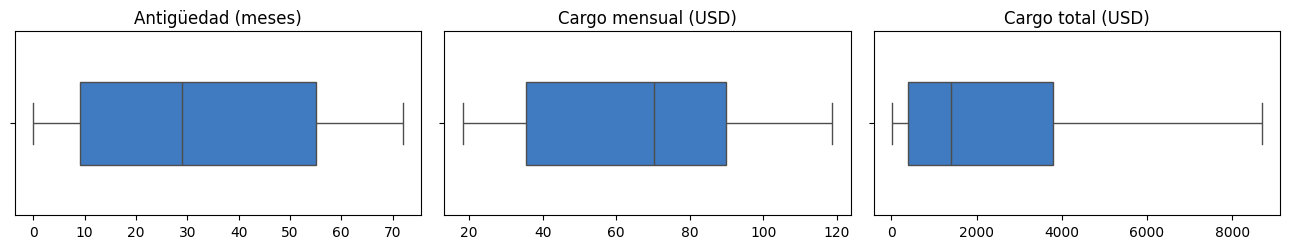

Consistencia TotalCharges vs. tenure × MonthlyCharges: {'desviacion_mediana_pct': 2.0, 'clientes_fuera_tolerancia': 27, 'pct_fuera_tolerancia': 0.38}


In [6]:
# Se revisan atípicos después de corregir tipos, que es cuando TotalCharges ya es numérica
numericas = pr.corregir_tipos(pr.estandarizar_texto(crudo))
display(pr.detectar_outliers_iqr(numericas).round(2))

fig, ejes = plt.subplots(1, 3, figsize=(13, 2.6))
for eje, col in zip(ejes, pr.COLS_NUMERICAS):
    sns.boxplot(x=numericas[col], ax=eje, color="#2a78d6", width=0.45, fliersize=2, linewidth=1)
    eje.set(title=pr.etiqueta(col), xlabel="")
plt.tight_layout()
plt.show()

print("Consistencia TotalCharges vs. tenure × MonthlyCharges:", pr.verificar_consistencia_cargos(numericas.fillna({"TotalCharges": 0})))

Ninguna variable numérica tiene valores por fuera de los límites de Tukey (Q1 − 1,5·IQR y Q3 + 1,5·IQR); los diagramas de caja no muestran puntos aislados. El cargo total se aleja en mediana apenas 2 % del producto antigüedad × cargo mensual, y solo 27 clientes (0,4 %) superan una diferencia del 25 %, algo esperable por cambios de plan o de tarifa. No hay evidencia de errores de captura, así que el tratamiento elegido es **conservar**.

### 3.3 Prueba de robustez del pipeline

El archivo original es bastante limpio, así que para comprobar que el código responde bien ante datos problemáticos creamos una copia con errores a propósito: filas duplicadas, espacios extra, una categoría mal escrita, un cargo negativo, un `TotalCharges` vacío y un cliente sin etiqueta de abandono.

In [7]:
sucio = crudo.copy()
sucio = pd.concat([sucio, sucio.iloc[[0, 1]]], ignore_index=True)   # 2 duplicados
sucio.loc[5, "gender"] = "  Male "                                    # espacios extra
sucio.loc[6, "Contract"] = "Monthly"                                  # categoría inválida
sucio.loc[7, "MonthlyCharges"] = -5                                   # valor imposible
sucio.loc[8, "TotalCharges"] = ""                                     # vacío con tenure > 0
sucio.loc[9, "Churn"] = None                                          # sin variable objetivo

prueba, bitacora_prueba = pr.preparar_datos(sucio)
display(bitacora_prueba)
print(f"Filas finales: {len(prueba):,} · nulos restantes: {int(prueba.isna().sum().sum())}")

,paso,detalle,filas
0,Carga,Archivo crudo,7045
1,Texto,Espacios recortados; 12 textos vacíos pasan a NaN,7045
2,Tipos,Columnas numéricas convertidas (0 valores no c...,7045
3,Duplicados,2 registros eliminados,7043
4,Dominios,"Valores fuera de dominio: Contract (1), Monthl...",7043
5,Nulos,"Imputaciones: filas_sin_id_o_churn (1), TotalC...",7042
6,Atípicos,0 atípicos por IQR; tratamiento: conservar,7042
7,Transformación,Categorías en español + 4 variables derivadas,7042


Filas finales: 7,042 · nulos restantes: 0


El pipeline elimina los duplicados, detecta la categoría y el cargo inválidos, estima el `TotalCharges` faltante como antigüedad × cargo mensual, descarta la fila sin etiqueta y termina sin nulos. Las validaciones con `assert` al final de `preparar_datos()` detendrían la ejecución si algo quedara mal.

### 3.4 Limpieza del dataset real

In [8]:
df, bitacora = pr.preparar_datos(crudo)
display(bitacora)

print(f"Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Nulos: {int(df.isna().sum().sum())} · IDs únicos: {df['customerID'].is_unique} · "
      f"Tasa de abandono: {df['abandono'].mean():.2%}")

df.to_csv("telco_churn_limpio.csv", index=False)
df.head()

,paso,detalle,filas
0,Carga,Archivo crudo,7043
1,Texto,Espacios recortados; 11 textos vacíos pasan a NaN,7043
2,Tipos,Columnas numéricas convertidas (0 valores no c...,7043
3,Duplicados,0 registros eliminados,7043
4,Dominios,Valores fuera de dominio: ninguno,7043
5,Nulos,Imputaciones: TotalCharges_cliente_nuevo (11),7043
6,Atípicos,0 atípicos por IQR; tratamiento: conservar,7043
7,Transformación,Categorías en español + 4 variables derivadas,7043


Dataset limpio: 7,043 filas × 25 columnas
Nulos: 0 · IDs únicos: True · Tasa de abandono: 26.54%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,abandono,num_servicios,pago_automatico,grupo_antiguedad
0,7590-VHVEG,Femenino,No,Sí,No,1,No,Sin servicio telefónico,DSL,No,Sí,No,No,No,No,Mes a mes,Sí,Cheque electrónico,29.85,29.85,No,0,1,No,0-12 meses
1,5575-GNVDE,Masculino,No,No,No,34,Sí,No,DSL,Sí,No,Sí,No,No,No,Un año,No,Cheque por correo,56.95,1889.50,No,0,2,No,25-48 meses
2,3668-QPYBK,Masculino,No,No,No,2,Sí,No,DSL,Sí,Sí,No,No,No,No,Mes a mes,Sí,Cheque por correo,53.85,108.15,Sí,1,2,No,0-12 meses
3,7795-CFOCW,Masculino,No,No,No,45,No,Sin servicio telefónico,DSL,Sí,No,Sí,Sí,No,No,Un año,No,Transferencia (automático),42.30,1840.75,No,0,3,Sí,25-48 meses
4,9237-HQITU,Femenino,No,No,No,2,Sí,No,Fibra óptica,No,No,No,No,No,No,Mes a mes,Sí,Cheque electrónico,70.70,151.65,Sí,1,0,No,0-12 meses


El resultado conserva los 7.043 clientes, sin nulos ni duplicados, con 25 columnas (21 originales y 4 derivadas) y las categorías en español. Se guarda una copia en `telco_churn_limpio.csv` por trazabilidad; el dashboard, en cambio, parte del archivo crudo y ejecuta este mismo pipeline al iniciar.

## 4. Análisis exploratorio avanzado

Las funciones estadísticas están en `analisis.py`, que también alimenta la pestaña *Análisis automático* del dashboard. En todas las pruebas usamos un nivel de significancia α = 0,05 y, además del valor p, reportamos el tamaño del efecto: con 7.043 registros casi cualquier diferencia resulta "significativa", así que lo importante es saber qué tan grande es.

In [9]:
%%writefile telco_dashboard/analisis.py
"""
analisis.py
-----------
Pruebas estadísticas y resúmenes automáticos sobre el dataset ya limpio.

Todas las funciones reciben un DataFrame, así que sirven igual para la base
completa (notebook) que para el subconjunto filtrado en el dashboard.
"""

import numpy as np
import pandas as pd
from scipy import stats

from procesamiento import COLS_CATEGORICAS, COLS_NUMERICAS, etiqueta

ALFA = 0.05


# ---------------------------------------------------------------------------
# Utilidades
# ---------------------------------------------------------------------------
def intervalo_wilson(exitos, n, confianza=0.95):
    """Intervalo de confianza de Wilson para una proporción.
    Se comporta mejor que el intervalo normal cuando n es pequeño."""
    if n == 0:
        return np.nan, np.nan
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    p = exitos / n
    centro = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    margen = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centro - margen, centro + margen


def magnitud_efecto(valor):
    """Interpretación de Cohen (1988) para V de Cramér con gl* = 1 y r biserial."""
    valor = abs(valor)
    if valor < 0.1:
        return "Despreciable"
    if valor < 0.3:
        return "Pequeño"
    if valor < 0.5:
        return "Mediano"
    return "Grande"


def fmt_num(valor, decimales=0):
    """Número con formato colombiano: punto de miles y coma decimal."""
    texto = f"{valor:,.{decimales}f}"
    return texto.replace(",", "_").replace(".", ",").replace("_", ".")


def fmt_pct(proporcion, decimales=1):
    return f"{fmt_num(100 * proporcion, decimales)} %"


def formato_p(p):
    # espacio no separable para que "p < 0,001" no se parta en dos líneas
    return "<\u00a00,001" if p < 0.001 else f"=\u00a0{fmt_num(p, 3)}"


# ---------------------------------------------------------------------------
# Descriptivos
# ---------------------------------------------------------------------------
def resumen_descriptivo(df, cols=None):
    """Estadísticos de tendencia, dispersión y forma para variables numéricas."""
    cols = cols or COLS_NUMERICAS
    tabla = df[cols].describe().T
    tabla["mediana"] = df[cols].median()
    tabla["asimetria"] = df[cols].skew()
    tabla["curtosis"] = df[cols].kurt()
    tabla["coef_variacion_%"] = 100 * tabla["std"] / tabla["mean"]
    tabla = tabla.rename(columns={"count": "n", "mean": "media", "std": "desv_est"})
    return tabla[["n", "media", "mediana", "desv_est", "min", "25%", "75%", "max",
                  "asimetria", "curtosis", "coef_variacion_%"]].round(2)


def tasa_abandono_por(df, col, confianza=0.95):
    """Clientes, abandonos y tasa de abandono por categoría, con IC de Wilson."""
    tabla = (
        df.groupby(col, observed=True)["abandono"]
        .agg(clientes="count", abandonos="sum")
        .reset_index()
    )
    tabla["tasa"] = tabla["abandonos"] / tabla["clientes"]
    ic = [intervalo_wilson(a, n, confianza) for a, n in zip(tabla["abandonos"], tabla["clientes"])]
    tabla["ic_inf"] = [i[0] for i in ic]
    tabla["ic_sup"] = [i[1] for i in ic]
    tabla["participacion"] = tabla["clientes"] / tabla["clientes"].sum()
    return tabla


# ---------------------------------------------------------------------------
# Pruebas de hipótesis
# ---------------------------------------------------------------------------
def prueba_normalidad(df, cols=None):
    """Prueba de D'Agostino-Pearson. Con n grande casi cualquier desviación
    resulta significativa, por eso se reporta junto a asimetría y curtosis."""
    cols = cols or COLS_NUMERICAS
    filas = []
    for col in cols:
        estadistico, p = stats.normaltest(df[col])
        filas.append({
            "variable": col,
            "asimetria": round(df[col].skew(), 3),
            "curtosis": round(df[col].kurt(), 3),
            "estadistico_K2": round(estadistico, 1),
            "p_valor": p,
            "normal": "Sí" if p >= ALFA else "No",
        })
    return pd.DataFrame(filas)


def cramers_v(tabla_contingencia):
    """V de Cramér a partir de una tabla de contingencia."""
    chi2 = stats.chi2_contingency(tabla_contingencia, correction=False)[0]
    n = tabla_contingencia.to_numpy().sum()
    k = min(tabla_contingencia.shape) - 1
    return float(np.sqrt(chi2 / (n * k))) if k > 0 and n > 0 else np.nan


def pruebas_chi_cuadrado(df, cols=None, objetivo="Churn"):
    """Chi-cuadrado de independencia de cada categórica frente al abandono.

    Incluye V de Cramér como tamaño del efecto, el porcentaje de frecuencias
    esperadas >= 5 (supuesto de la prueba) y la corrección de Bonferroni por
    realizar varias pruebas a la vez."""
    cols = cols or COLS_CATEGORICAS
    filas = []
    for col in cols:
        tabla = pd.crosstab(df[col], df[objetivo])
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
        chi2, p, gl, esperadas = stats.chi2_contingency(tabla, correction=False)
        filas.append({
            "variable": col,
            "nombre": etiqueta(col),
            "chi2": round(chi2, 2),
            "gl": gl,
            "p_valor": p,
            "v_cramer": round(cramers_v(tabla), 3),
            "esperadas_>=5_%": round(100 * (esperadas >= 5).mean(), 1),
        })
    if not filas:
        return pd.DataFrame()
    resultado = pd.DataFrame(filas)
    m = len(resultado)
    resultado["p_bonferroni"] = (resultado["p_valor"] * m).clip(upper=1)
    resultado["significativa"] = np.where(resultado["p_bonferroni"] < ALFA, "Sí", "No")
    resultado["efecto"] = resultado["v_cramer"].apply(magnitud_efecto)
    return resultado.sort_values("v_cramer", ascending=False).reset_index(drop=True)


def comparar_numericas(df, cols=None):
    """U de Mann-Whitney entre clientes que abandonan y los que se quedan.

    Se usa una prueba no paramétrica porque las variables no son normales.
    El tamaño del efecto es la correlación biserial por rangos:
    r = 1 - 2U / (n1·n2); r > 0 indica valores mayores en quienes abandonan."""
    cols = cols or COLS_NUMERICAS
    filas = []
    si = df[df["abandono"] == 1]
    no = df[df["abandono"] == 0]
    if si.empty or no.empty:
        return pd.DataFrame()
    for col in cols:
        u, p = stats.mannwhitneyu(no[col], si[col], alternative="two-sided")
        r = 1 - 2 * u / (len(si) * len(no))
        filas.append({
            "variable": col,
            "nombre": etiqueta(col),
            "mediana_se_queda": round(no[col].median(), 2),
            "mediana_abandona": round(si[col].median(), 2),
            "U": round(u, 0),
            "p_valor": p,
            "r_biserial": round(r, 3),
            "efecto": magnitud_efecto(r),
        })
    return pd.DataFrame(filas)


def prueba_kruskal(df, numerica, categorica):
    """Kruskal-Wallis: ¿la distribución de una numérica cambia entre grupos?"""
    grupos = [g[numerica].to_numpy() for _, g in df.groupby(categorica, observed=True)]
    h, p = stats.kruskal(*grupos)
    n, k = len(df), len(grupos)
    eta2_h = (h - k + 1) / (n - k)  # tamaño del efecto η²H (Tomczak y Tomczak, 2014)
    return {"H": round(float(h), 2), "gl": k - 1, "p_valor": float(p), "eta2_H": round(float(eta2_h), 3)}


def prueba_tasa_vs_global(abandonos, clientes, tasa_global):
    """Prueba binomial: ¿la tasa de un segmento difiere de la tasa global?"""
    if clientes == 0:
        return np.nan
    return stats.binomtest(int(abandonos), int(clientes), tasa_global).pvalue


# ---------------------------------------------------------------------------
# Correlaciones
# ---------------------------------------------------------------------------
def matriz_correlacion(df, cols=None, metodo="spearman"):
    cols = cols or COLS_NUMERICAS + ["num_servicios", "abandono"]
    return df[cols].corr(method=metodo)


def matriz_cramers_v(df, cols):
    """Matriz simétrica de V de Cramér entre variables categóricas."""
    matriz = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            v = cramers_v(pd.crosstab(df[a], df[b]))
            matriz.loc[a, b] = matriz.loc[b, a] = v
    return matriz


# ---------------------------------------------------------------------------
# Análisis automático (lo consume el dashboard)
# ---------------------------------------------------------------------------
def kpis(df):
    clientes = len(df)
    abandonos = int(df["abandono"].sum())
    return {
        "clientes": clientes,
        "abandonos": abandonos,
        "tasa": abandonos / clientes if clientes else np.nan,
        "ingreso_mensual": float(df["MonthlyCharges"].sum()),
        "ingreso_en_riesgo": float(df.loc[df["abandono"] == 1, "MonthlyCharges"].sum()),
        "antiguedad_media": float(df["tenure"].mean()) if clientes else np.nan,
    }


def segmentos_criticos(df, cols=None, min_clientes=100, top=5):
    """Busca las categorías con mayor tasa de abandono (con tamaño mínimo)."""
    cols = cols or COLS_CATEGORICAS + ["grupo_antiguedad", "pago_automatico"]
    tablas = []
    for col in cols:
        if df[col].nunique() < 2:  # variable ya fijada por un filtro
            continue
        t = tasa_abandono_por(df, col)
        t = t[t["clientes"] >= min_clientes]
        t.insert(0, "variable", etiqueta(col))
        tablas.append(t.rename(columns={col: "categoria"}))
    if not tablas:
        return pd.DataFrame()
    todo = pd.concat(tablas, ignore_index=True)
    return todo.sort_values("tasa", ascending=False).head(top).reset_index(drop=True)


def analisis_automatico(df_filtrado, df_total):
    """Genera hallazgos en texto a partir del subconjunto filtrado.

    Devuelve un diccionario con los hallazgos, las tablas de pruebas y un
    indicador de si hubo datos suficientes para aplicar las pruebas."""
    resultado = {"hallazgos": [], "suficiente": True}
    n = len(df_filtrado)
    abandonos = int(df_filtrado["abandono"].sum())
    clase_menor = min(abandonos, n - abandonos)
    if n < 30 or clase_menor < 10:
        resultado["suficiente"] = False
        resultado["hallazgos"].append(
            f"La selección tiene {fmt_num(n)} clientes y {fmt_num(abandonos)} "
            f"{'abandono' if abandonos == 1 else 'abandonos'}. "
            "Se necesitan al menos 30 clientes y 10 casos en cada grupo (abandona / "
            "permanece) para que las pruebas sean confiables; amplíe los filtros."
        )
        return resultado

    k_seg, k_tot = kpis(df_filtrado), kpis(df_total)
    diferencia = 100 * (k_seg["tasa"] - k_tot["tasa"])
    p_seg = prueba_tasa_vs_global(k_seg["abandonos"], n, k_tot["tasa"])
    comparacion = "por encima" if diferencia > 0 else "por debajo"
    if n == len(df_total):
        texto = (f"La base completa tiene {fmt_num(n)} clientes y una tasa de abandono "
                 f"de {fmt_pct(k_tot['tasa'])}.")
    elif p_seg < ALFA:
        texto = (f"La selección ({fmt_num(n)} clientes) tiene una tasa de abandono de "
                 f"{fmt_pct(k_seg['tasa'])}, {fmt_num(abs(diferencia), 1)} puntos {comparacion} "
                 f"del total. La diferencia es estadísticamente significativa "
                 f"(prueba binomial, p {formato_p(p_seg)}).")
    else:
        texto = (f"La selección ({fmt_num(n)} clientes) tiene una tasa de abandono de "
                 f"{fmt_pct(k_seg['tasa'])}, sin diferencia significativa frente al total "
                 f"({fmt_pct(k_tot['tasa'])}; p {formato_p(p_seg)}).")
    resultado["hallazgos"].append(texto)

    participacion = k_seg["ingreso_en_riesgo"] / k_seg["ingreso_mensual"]
    resultado["hallazgos"].append(
        f"Los clientes que abandonaron representaban USD {fmt_num(k_seg['ingreso_en_riesgo'])} "
        f"de facturación mensual, el {fmt_pct(participacion)} del ingreso de la selección."
    )

    chi = pruebas_chi_cuadrado(df_filtrado)
    resultado["chi_cuadrado"] = chi
    validas = chi[(chi["significativa"] == "Sí") & (chi["esperadas_>=5_%"] >= 80)] if not chi.empty else chi
    if not validas.empty:
        top = validas.iloc[0]
        tabla_top = tasa_abandono_por(df_filtrado, top["variable"]).sort_values("tasa")
        alta, baja = tabla_top.iloc[-1], tabla_top.iloc[0]
        resultado["hallazgos"].append(
            f"La variable más asociada al abandono es «{top['nombre']}» "
            f"(V de Cramér = {fmt_num(top['v_cramer'], 2)}, efecto {top['efecto'].lower()}): "
            f"la tasa va de {fmt_pct(baja['tasa'])} en «{baja[top['variable']]}» a "
            f"{fmt_pct(alta['tasa'])} en «{alta[top['variable']]}»."
        )

    mw = comparar_numericas(df_filtrado)
    resultado["mann_whitney"] = mw
    if not mw.empty:
        fila = mw.loc[mw["r_biserial"].abs().idxmax()]
        if fila["p_valor"] < ALFA:
            sentido = "mayor" if fila["r_biserial"] > 0 else "menor"
            resultado["hallazgos"].append(
                f"Quienes abandonan tienen {sentido} «{fila['nombre']}»: mediana de "
                f"{fmt_num(fila['mediana_abandona'], 1)} frente a {fmt_num(fila['mediana_se_queda'], 1)} "
                f"en quienes permanecen (Mann-Whitney, p {formato_p(fila['p_valor'])}; "
                f"r\u00a0=\u00a0{fmt_num(fila['r_biserial'], 2)})."
            )

    seg = segmentos_criticos(df_filtrado, min_clientes=max(30, int(0.03 * n)))
    resultado["segmentos"] = seg
    if not seg.empty:
        s = seg.iloc[0]
        resultado["hallazgos"].append(
            f"El segmento de mayor riesgo es «{s['variable']}: {s['categoria']}», con "
            f"{fmt_pct(s['tasa'])} de abandono entre {fmt_num(s['clientes'])} clientes "
            f"(IC 95 %: {fmt_pct(s['ic_inf'])} a {fmt_pct(s['ic_sup'])})."
        )

    resultado["descriptivos"] = resumen_descriptivo(df_filtrado)
    return resultado

Writing telco_dashboard/analisis.py


Las funciones de visualización del notebook usan Matplotlib y Seaborn, porque generan imágenes estáticas que se ven igual en Colab, en GitHub y en el reporte PDF. Mantienen los mismos colores del dashboard: azul para quienes permanecen y naranja para quienes abandonan (combinación legible para personas con daltonismo).

In [10]:
import analisis as an

AZUL, NARANJA, GRIS = "#2a78d6", "#eb6834", "#c3c2b7"
TINTA_SEC, GUIA = "#52514e", "#e1e0d9"
PALETA_ESTADO = {"Permanece": AZUL, "Abandona": NARANJA}
ORDEN_ESTADO = ["Permanece", "Abandona"]
CARPETA_FIGURAS = Path("figuras")
CARPETA_FIGURAS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=0.95, rc={
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA_SEC, "axes.titlesize": 11.5,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "grid.color": GUIA,
    "xtick.color": TINTA_SEC, "ytick.color": TINTA_SEC, "legend.frameon": False,
    "figure.dpi": 100, "savefig.dpi": 200, "savefig.bbox": "tight",
})
PCT = mtick.PercentFormatter(1.0, decimals=0)


def con_estado(datos):
    """Agrega la columna 'Estado' (Permanece / Abandona) para las leyendas."""
    return datos.assign(Estado=datos["Churn"].map({"No": "Permanece", "Sí": "Abandona"}))


def mostrar_y_guardar(fig, nombre):
    """Guarda la figura en figuras/ (se usa en el reporte) y la muestra."""
    fig.savefig(CARPETA_FIGURAS / f"{nombre}.png")
    plt.show()


def ordenar_tabla(tabla, col):
    """Orden lógico si existe; si la variable es numérica, ascendente; si no, por tasa."""
    if col in pr.ORDEN_CATEGORIAS:
        orden = [c for c in pr.ORDEN_CATEGORIAS[col] if c in set(tabla[col])]
        return tabla.set_index(col).loc[orden].reset_index()
    if pd.api.types.is_numeric_dtype(tabla[col]):
        return tabla.sort_values(col)
    return tabla.sort_values("tasa", ascending=False)


def graficar_distribuciones(datos, cols, nombre, ancho_panel=5.2, alto=6):
    """Histograma (% dentro de cada grupo) y diagrama de caja según el estado del cliente."""
    datos = con_estado(datos)
    fig, ejes = plt.subplots(2, len(cols), figsize=(ancho_panel * len(cols), alto),
                             gridspec_kw={"height_ratios": [3, 1]}, sharex="col")
    for i, col in enumerate(cols):
        sns.histplot(data=datos, x=col, hue="Estado", hue_order=ORDEN_ESTADO, palette=PALETA_ESTADO,
                     stat="percent", common_norm=False, bins=30, element="step", alpha=0.2,
                     kde=True, ax=ejes[0, i], legend=(i == len(cols) - 1))
        ejes[0, i].set(title=pr.etiqueta(col), xlabel="", ylabel="% de clientes del grupo" if i == 0 else "")
        sns.boxplot(data=datos, x=col, y="Estado", hue="Estado", order=ORDEN_ESTADO, palette=PALETA_ESTADO,
                    width=0.55, fliersize=2, linewidth=1, ax=ejes[1, i], legend=False)
        ejes[1, i].set(xlabel=pr.etiqueta(col), ylabel="")
    sns.move_legend(ejes[0, -1], "upper right", title=None)
    fig.tight_layout()
    mostrar_y_guardar(fig, nombre)


def graficar_tasas(datos, cols, nombre, titulo=None, ncols=3, ancho_panel=5.3, alto_fila=2.7):
    """Tasa de abandono por categoría con intervalo de confianza de Wilson al 95 %."""
    tasa_global = datos["abandono"].mean()
    nfilas = int(np.ceil(len(cols) / ncols))
    fig, ejes = plt.subplots(nfilas, ncols, figsize=(ancho_panel * ncols, alto_fila * nfilas), squeeze=False, layout="constrained")
    for eje, col in zip(ejes.flat, cols):
        tabla = ordenar_tabla(an.tasa_abandono_por(datos, col), col)
        y = np.arange(len(tabla))
        grosor = float(np.clip(0.16 * len(tabla), 0.3, 0.7))  # barras de grosor parecido entre paneles
        errores = [tabla["tasa"] - tabla["ic_inf"], tabla["ic_sup"] - tabla["tasa"]]
        eje.barh(y, tabla["tasa"], height=grosor, color=AZUL, xerr=errores,
                 error_kw=dict(ecolor=TINTA_SEC, lw=0.8, capsize=2))
        eje.axvline(tasa_global, color=TINTA_SEC, lw=0.8)
        for yi, (tasa, sup) in enumerate(zip(tabla["tasa"], tabla["ic_sup"])):
            eje.text(sup + 0.012, yi, an.fmt_pct(tasa), va="center", fontsize=8.5, color=TINTA_SEC)
        eje.set_yticks(y, tabla[col].astype(str))
        eje.set_ylim(len(tabla) - 0.4, -0.6)
        eje.set_xlim(0, min(1.0, tabla["ic_sup"].max() + 0.16))
        eje.xaxis.set_major_formatter(PCT)
        eje.grid(axis="y", visible=False)
        eje.set_title(pr.etiqueta(col))
    for eje in list(ejes.flat)[len(cols):]:
        eje.set_visible(False)
    if titulo:
        fig.suptitle(titulo, x=0.01, ha="left", fontsize=13, fontweight="semibold")
    mostrar_y_guardar(fig, nombre)


def graficar_ranking_v(tabla_chi, nombre):
    """Barras de V de Cramér; en gris las variables sin asociación significativa."""
    tabla = tabla_chi.sort_values("v_cramer")
    colores = np.where(tabla["significativa"] == "Sí", AZUL, GRIS)
    fig, eje = plt.subplots(figsize=(8.5, 5.6))
    eje.barh(tabla["nombre"], tabla["v_cramer"], color=colores, height=0.6)
    for yi, v in enumerate(tabla["v_cramer"]):
        eje.text(v + 0.004, yi, an.fmt_num(v, 2), va="center", fontsize=8.5, color=TINTA_SEC)
    for x, texto in [(0.1, "efecto pequeño"), (0.3, "efecto mediano")]:
        eje.axvline(x, color=GRIS, lw=0.9, zorder=0)
        eje.text(x + 0.004, len(tabla) - 0.4, texto, fontsize=8, color=TINTA_SEC)
    eje.legend(handles=[Patch(color=AZUL, label="Significativa (Bonferroni)"),
                        Patch(color=GRIS, label="No significativa")], loc="lower right")
    eje.set(title="Fuerza de asociación con el abandono (V de Cramér)", xlabel="V de Cramér", ylabel="")
    eje.grid(axis="y", visible=False)
    fig.tight_layout()
    mostrar_y_guardar(fig, nombre)


def graficar_mapa_calor(matriz, titulo, eje, cmap="RdBu_r", vmin=-1, vmax=1, etiquetas=None):
    """Mapa de calor anotado para matrices de correlación o asociación."""
    etiquetas = etiquetas or {}
    nombres = [etiquetas.get(c, pr.etiqueta(c)) for c in matriz.columns]
    anotaciones = matriz.map(lambda v: an.fmt_num(v, 2)) if hasattr(matriz, "map") else matriz.applymap(lambda v: an.fmt_num(v, 2))
    sns.heatmap(matriz, annot=anotaciones, fmt="", cmap=cmap, vmin=vmin, vmax=vmax, square=True,
                linewidths=2, linecolor="white", cbar_kws={"shrink": 0.75}, ax=eje,
                xticklabels=nombres, yticklabels=nombres, annot_kws={"fontsize": 9})
    eje.set_title(titulo)
    eje.tick_params(axis="x", rotation=35)
    plt.setp(eje.get_xticklabels(), ha="right")


def graficar_segmentos(datos, fila, columna, eje):
    """Tasa de abandono al cruzar dos variables categóricas."""
    tabla = datos.groupby([fila, columna], observed=True)["abandono"].agg(["mean", "count"]).reset_index()
    tasas = tabla.pivot(index=fila, columns=columna, values="mean")
    conteos = tabla.pivot(index=fila, columns=columna, values="count")
    for eje_orden, col in [(0, fila), (1, columna)]:
        if col in pr.ORDEN_CATEGORIAS:
            orden = [c for c in pr.ORDEN_CATEGORIAS[col] if c in (tasas.index if eje_orden == 0 else tasas.columns)]
            tasas = tasas.reindex(orden, axis=eje_orden)
            conteos = conteos.reindex(orden, axis=eje_orden)
    anot = np.array([[f"{an.fmt_pct(t)}\nn = {an.fmt_num(c)}" for t, c in zip(ft, fc)]
                     for ft, fc in zip(tasas.to_numpy(), conteos.to_numpy())])
    sns.heatmap(tasas, annot=anot, fmt="", cmap="Blues", vmin=0, vmax=0.6, linewidths=2, linecolor="white",
                cbar_kws={"format": PCT, "shrink": 0.8}, ax=eje, annot_kws={"fontsize": 9})
    eje.set(title=f"Tasa de abandono: {pr.etiqueta(fila).lower()} × {pr.etiqueta(columna).lower()}",
            xlabel=pr.etiqueta(columna), ylabel=pr.etiqueta(fila))
    eje.tick_params(axis="y", rotation=0)

### 4.1 Variable objetivo

In [11]:
k = an.kpis(df)
resumen_objetivo = (df["Churn"].value_counts().rename_axis("Abandono").to_frame("clientes")
                    .assign(porcentaje=lambda t: (100 * t["clientes"] / t["clientes"].sum()).round(1)))
display(resumen_objetivo)

print(f"Clientes perdidos: {k['abandonos']:,} de {k['clientes']:,} ({k['tasa']:.1%})")
print(f"Ingreso mensual de la base: USD {k['ingreso_mensual']:,.0f}")
print(f"Ingreso mensual de quienes abandonaron: USD {k['ingreso_en_riesgo']:,.0f} "
      f"({k['ingreso_en_riesgo'] / k['ingreso_mensual']:.1%})")
print(df.groupby("Churn")["MonthlyCharges"].mean().round(2).rename("cargo_mensual_promedio"))

,clientes,porcentaje
Abandono,,
No,5174,73.5
Sí,1869,26.5


Clientes perdidos: 1,869 de 7,043 (26.5%)
Ingreso mensual de la base: USD 456,117
Ingreso mensual de quienes abandonaron: USD 139,131 (30.5%)
Churn
No    61.27
Sí    74.44
Name: cargo_mensual_promedio, dtype: float64


De los 7.043 clientes, 1.869 abandonaron la compañía (26,5 %). Las clases están desbalanceadas en proporción cercana a 3:1, un punto a considerar si más adelante se entrena un modelo predictivo. Ese grupo facturaba USD 139.131 al mes, el 30,5 % del ingreso total: la participación en ingreso supera la participación en clientes porque quienes se van pagan más en promedio (USD 74,44 frente a USD 61,27).

### 4.2 Estadística descriptiva

In [12]:
display(an.resumen_descriptivo(df))
display(df.groupby("Churn")[pr.COLS_NUMERICAS].agg(["mean", "median"]).round(2))

,n,media,mediana,desv_est,min,25%,75%,max,asimetria,curtosis,coef_variacion_%
tenure,7043.0,32.37,29.00,24.56,0.00,9.00,55.00,72.00,0.24,-1.39,75.87
MonthlyCharges,7043.0,64.76,70.35,30.09,18.25,35.50,89.85,118.75,-0.22,-1.26,46.46
TotalCharges,7043.0,2279.73,1394.55,2266.79,0.00,398.55,3786.60,8684.80,0.96,-0.23,99.43


tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2549.91  1679.52
Sí     17.98   10.0          74.44  79.65      1531.80   703.55

- **Antigüedad (`tenure`)**: va de 0 a 72 meses, con media de 32,4 y un coeficiente de variación de 75,9 %. La base mezcla clientes muy nuevos con otros de seis años.
- **Cargo mensual**: la mediana (USD 70,35) está por encima de la media (USD 64,76). Hay un grupo numeroso de planes económicos, cerca de USD 20, que corresponde a clientes sin internet.
- **Cargo total**: es la más asimétrica (0,96) porque combina antigüedad y tarifa.
- Al separar por grupo, quienes abandonan tienen una mediana de 10 meses de antigüedad frente a 38 de quienes permanecen, y pagan más al mes (USD 79,65 frente a USD 64,43 en mediana).

### 4.3 Distribuciones y normalidad

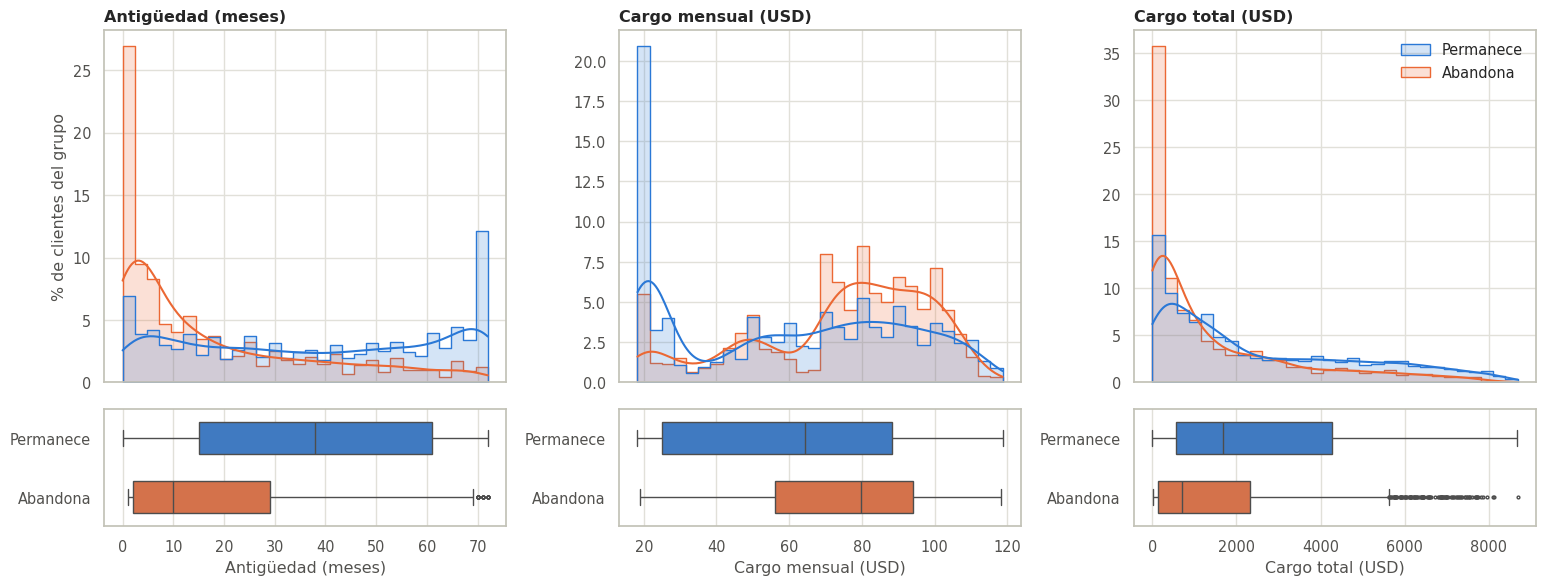

In [13]:
graficar_distribuciones(df, pr.COLS_NUMERICAS, "fig01_distribuciones")

In [14]:
normalidad = an.prueba_normalidad(df)
display(normalidad.style.format({"p_valor": "{:.2e}"}).hide(axis="index"))

variable,asimetria,curtosis,estadistico_K2,p_valor,normal
tenure,0.240000,-1.387000,76258.500000,0.00e+00,No
MonthlyCharges,-0.221000,-1.257000,11419.500000,0.00e+00,No
TotalCharges,0.963000,-0.229000,808.600000,2.60e-176,No


**Hipótesis (D'Agostino-Pearson):** H₀: la variable sigue una distribución normal; H₁: no la sigue.

Las tres variables rechazan H₀ (p < 0,001). Los gráficos confirman que no es un efecto del tamaño de muestra: `tenure` tiene forma de U, con picos en 1 mes (613 clientes) y en 72 meses (362), y curtosis negativa; el cargo mensual es bimodal; el cargo total tiene cola larga a la derecha. Por eso las comparaciones entre grupos se hacen con pruebas no paramétricas (Mann-Whitney y Kruskal-Wallis) y las correlaciones se leen con Spearman.

En los histogramas se ve el patrón central del análisis: la mayoría de clientes que abandonan lo hacen en los primeros meses y con cargos mensuales entre USD 70 y USD 105, mientras que la distribución de quienes permanecen se carga hacia las antigüedades altas.

### 4.4 Tasa de abandono por variable categórica

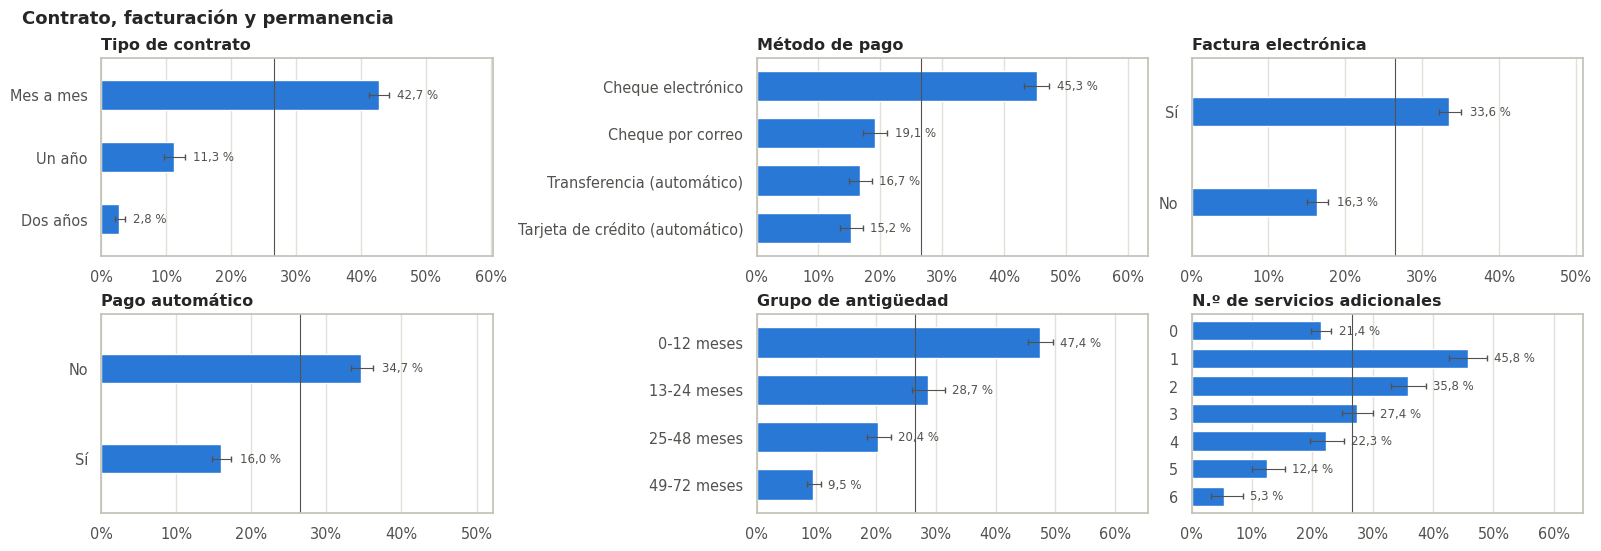

In [15]:
graficar_tasas(df, ["Contract", "PaymentMethod", "PaperlessBilling", "pago_automatico", "grupo_antiguedad", "num_servicios"],
               "fig02_tasas_contrato", titulo="Contrato, facturación y permanencia")

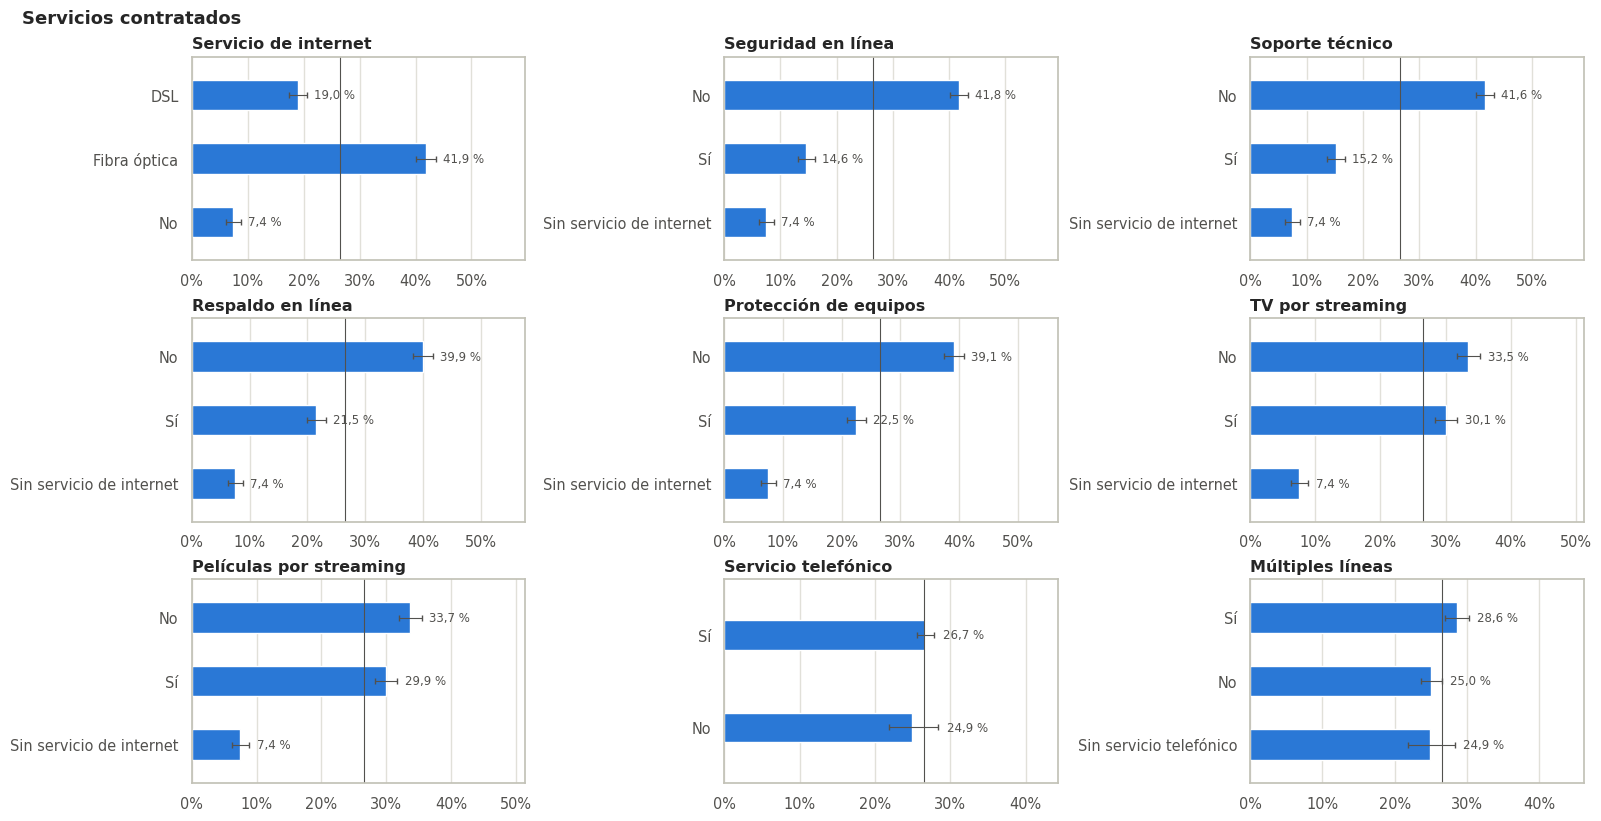

In [16]:
graficar_tasas(df, ["InternetService", "OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection",
                    "StreamingTV", "StreamingMovies", "PhoneService", "MultipleLines"],
               "fig03_tasas_servicios", titulo="Servicios contratados")

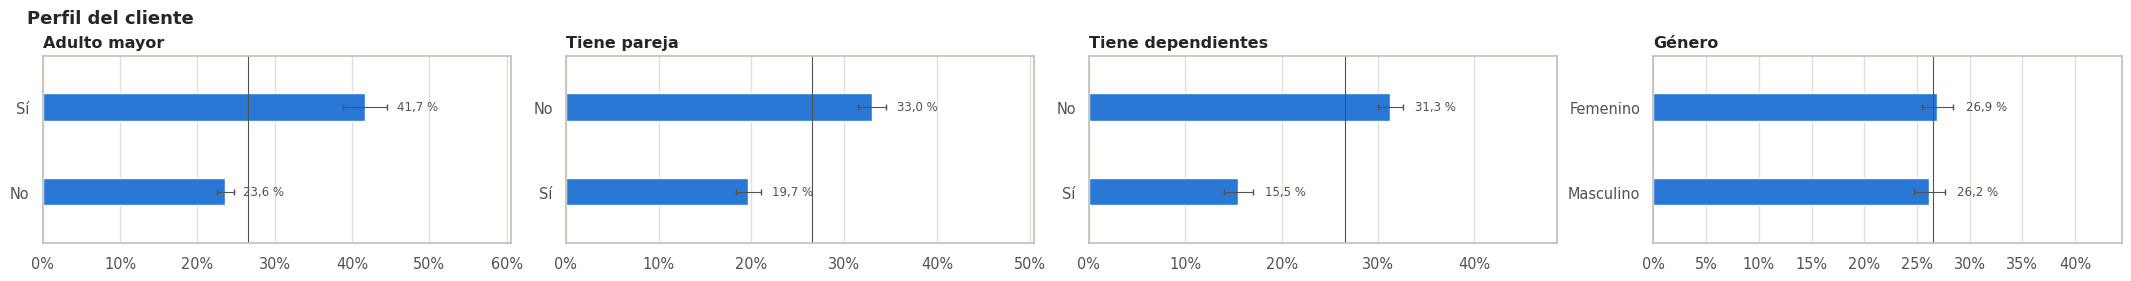

In [17]:
graficar_tasas(df, ["SeniorCitizen", "Partner", "Dependents", "gender"], "fig04_tasas_perfil",
               titulo="Perfil del cliente", ncols=4)

La línea vertical marca la tasa global (26,5 %) y las barras de error el intervalo de confianza del 95 %.

- **Contrato**: es la diferencia más marcada. Los contratos mes a mes tienen 42,7 % de abandono, los de un año 11,3 % y los de dos años 2,8 %; un cliente mes a mes se retira unas 15 veces más que uno con contrato de dos años.
- **Pago y facturación**: el cheque electrónico llega a 45,3 %, mientras los medios automáticos (tarjeta y transferencia) se quedan entre 15 % y 17 %. La factura electrónica también aparece asociada a más abandono (33,6 % frente a 16,3 %).
- **Permanencia**: en el primer año se retira el 47,4 % de los clientes; después de cuatro años, el 9,5 %.
- **Servicios**: la fibra óptica tiene 41,9 % de abandono, más del doble que DSL (19,0 %). Quienes no tienen seguridad en línea o soporte técnico abandonan cerca del 42 %, frente a 15 % de quienes sí los tienen. El *streaming* casi no cambia la tasa y la telefonía no la cambia.
- **Número de servicios**: con un solo servicio adicional la tasa es 45,8 % y baja de forma sostenida hasta 5,3 % con seis. El grupo con cero servicios (21,4 %) incluye a los clientes sin internet, que casi no se retiran.
- **Perfil**: los adultos mayores abandonan más (41,7 % frente a 23,6 %), igual que quienes no tienen pareja o dependientes. El género no marca diferencia (26,9 % frente a 26,2 %).

### 4.5 Pruebas de hipótesis

**Chi-cuadrado de independencia.** H₀: la variable y el abandono son independientes. Como se hacen 16 pruebas a la vez, se aplica la corrección de Bonferroni (equivale a exigir p < 0,05/16 ≈ 0,003) para no acumular falsos positivos. El tamaño del efecto es la V de Cramér; con una variable objetivo binaria se interpreta con los umbrales de Cohen (1988): 0,1 pequeño, 0,3 mediano y 0,5 grande.

nombre,chi2,gl,p_valor,v_cramer,esperadas_>=5_%,p_bonferroni,significativa,efecto
Tipo de contrato,"1,184.6",2,5.86e-258,0.410,100.000000,9.38e-257,Sí,Mediano
Seguridad en línea,850.0,2,2.66e-185,0.347,100.000000,4.26e-184,Sí,Mediano
Soporte técnico,828.2,2,1.44e-180,0.343,100.000000,2.31e-179,Sí,Mediano
Servicio de internet,732.3,2,9.57e-160,0.322,100.000000,1.53e-158,Sí,Mediano
Método de pago,648.1,3,3.68e-140,0.303,100.000000,5.89e-139,Sí,Mediano
Respaldo en línea,601.8,2,2.08e-131,0.292,100.000000,3.33e-130,Sí,Pequeño
Protección de equipos,558.4,2,5.51e-122,0.282,100.000000,8.81e-121,Sí,Pequeño
TV por streaming,374.2,2,5.53e-82,0.231,100.000000,8.85e-81,Sí,Pequeño
Películas por streaming,375.7,2,2.67e-82,0.231,100.000000,4.27e-81,Sí,Pequeño
Factura electrónica,259.2,1,2.61e-58,0.192,100.000000,4.18e-57,Sí,Pequeño


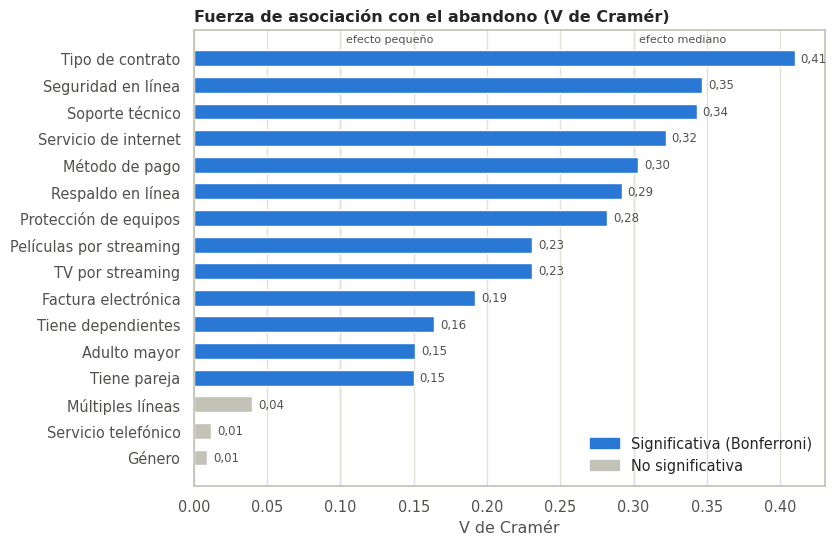

In [18]:
chi = an.pruebas_chi_cuadrado(df)
display(chi.drop(columns="variable").style
        .format({"p_valor": "{:.2e}", "p_bonferroni": "{:.2e}", "chi2": "{:,.1f}", "v_cramer": "{:.3f}"})
        .hide(axis="index"))
graficar_ranking_v(chi, "fig05_ranking_cramer")

Trece de las dieciséis variables tienen asociación significativa con el abandono. Género y servicio telefónico no la tienen, y múltiples líneas deja de serlo al corregir por Bonferroni (p ajustado = 0,055). En todas las tablas el 100 % de las frecuencias esperadas es mayor o igual a 5, así que el supuesto de la prueba se cumple.

Las asociaciones más fuertes, todas de efecto mediano, son tipo de contrato (V = 0,41), seguridad en línea (0,35), soporte técnico (0,34), servicio de internet (0,32) y método de pago (0,30). Las variables de perfil (adulto mayor, pareja, dependientes) son significativas pero con efecto pequeño.

**U de Mann-Whitney.** H₀: la distribución de la variable es igual en quienes abandonan y en quienes permanecen. El tamaño del efecto es la correlación biserial por rangos *r*; un valor negativo indica valores más bajos en quienes abandonan.

In [19]:
mw = an.comparar_numericas(df)
display(mw.drop(columns="variable").style.format({"p_valor": "{:.2e}", "U": "{:,.0f}"}).hide(axis="index"))

nombre,mediana_se_queda,mediana_abandona,U,p_valor,r_biserial,efecto
Antigüedad (meses),38.000000,10.000000,"7,154,668",2.42e-208,-0.480000,Mediano
Cargo mensual (USD),64.430000,79.650000,"3,667,080",3.31e-54,0.242000,Pequeño
Cargo total (USD),1679.520000,703.550000,"6,288,982",5.69e-83,-0.301000,Mediano


Las tres diferencias son significativas (p < 0,001). La antigüedad tiene el efecto más grande (r = −0,48): quienes se van llevan mucho menos tiempo. El cargo total (r = −0,30) sigue el mismo patrón porque depende de la antigüedad. El cargo mensual va en sentido contrario (r = 0,24, efecto pequeño): los clientes que abandonan pagan más cada mes.

**Kruskal-Wallis.** Sirve para ver cómo se relacionan entre sí las variables que más explican el abandono. El tamaño del efecto es η²H (Tomczak y Tomczak, 2014), con umbrales de 0,01 pequeño, 0,06 mediano y 0,14 grande.

In [20]:
kruskal = pd.DataFrame.from_dict({
    "Antigüedad según contrato": an.prueba_kruskal(df, "tenure", "Contract"),
    "Cargo mensual según internet": an.prueba_kruskal(df, "MonthlyCharges", "InternetService"),
    "Cargo mensual según contrato": an.prueba_kruskal(df, "MonthlyCharges", "Contract"),
}, orient="index")
display(kruskal.style.format({"H": "{:,.1f}", "p_valor": "{:.2e}", "eta2_H": "{:.3f}"}))
display(df.groupby("InternetService")["MonthlyCharges"].median().rename("mediana_cargo_mensual").to_frame())

,H,gl,p_valor,eta2_H
Antigüedad según contrato,"3,139.2",2,0.00e+00,0.446
Cargo mensual según internet,"5,529.7",2,0.00e+00,0.785
Cargo mensual según contrato,21.2,2,2.46e-05,0.003


,mediana_cargo_mensual
InternetService,
DSL,56.150
Fibra óptica,91.675
No,20.150


- La antigüedad cambia mucho según el contrato (η²H = 0,45, efecto grande): los contratos largos pertenecen a clientes con más tiempo en la empresa. Contrato y antigüedad cuentan, en parte, la misma historia.
- El cargo mensual depende sobre todo del tipo de internet (η²H = 0,79). La fibra óptica es el servicio más caro, con mediana de USD 91,68 frente a USD 56,15 en DSL.
- El cargo mensual casi no cambia con el contrato (η²H = 0,003): los contratos largos no son más baratos, lo que descarta el precio como explicación de su baja tasa de abandono.

### 4.6 Correlaciones

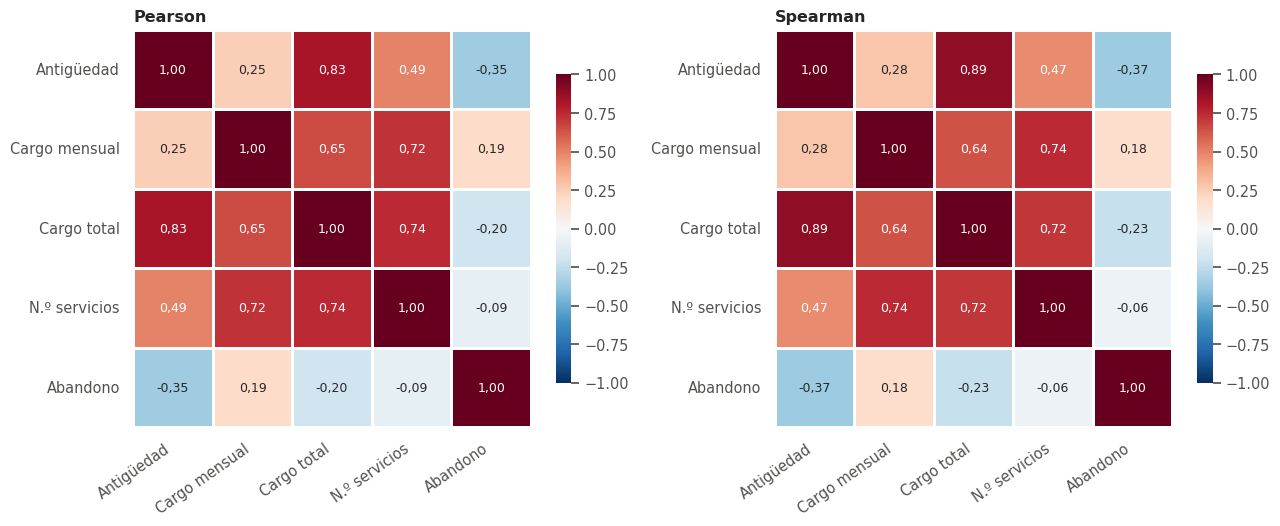

In [21]:
cortas = {"tenure": "Antigüedad", "MonthlyCharges": "Cargo mensual", "TotalCharges": "Cargo total",
          "num_servicios": "N.º servicios", "abandono": "Abandono"}
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.2))
graficar_mapa_calor(an.matriz_correlacion(df, metodo="pearson"), "Pearson", ejes[0], etiquetas=cortas)
graficar_mapa_calor(an.matriz_correlacion(df, metodo="spearman"), "Spearman", ejes[1], etiquetas=cortas)
fig.tight_layout()
mostrar_y_guardar(fig, "fig06_correlaciones")

Pearson y Spearman dan resultados parecidos, aunque tomamos Spearman como referencia porque ninguna variable es normal. Tres lecturas:

1. **Redundancia**: antigüedad y cargo total tienen ρ = 0,89. El cargo total es prácticamente antigüedad × tarifa, así que en un modelo predictivo convendría no usar ambas (multicolinealidad).
2. **Relación con el abandono**: la antigüedad es la variable numérica más relacionada (ρ = −0,37), seguida del cargo total (−0,23) y el cargo mensual (+0,18). El número de servicios apenas se relaciona de forma lineal (−0,06) porque su efecto no es monótono, como se vio en 4.4.
3. **Servicios y precio**: el número de servicios adicionales explica buena parte del cargo mensual (ρ = 0,74).

Entre variables categóricas se usa la V de Cramér:

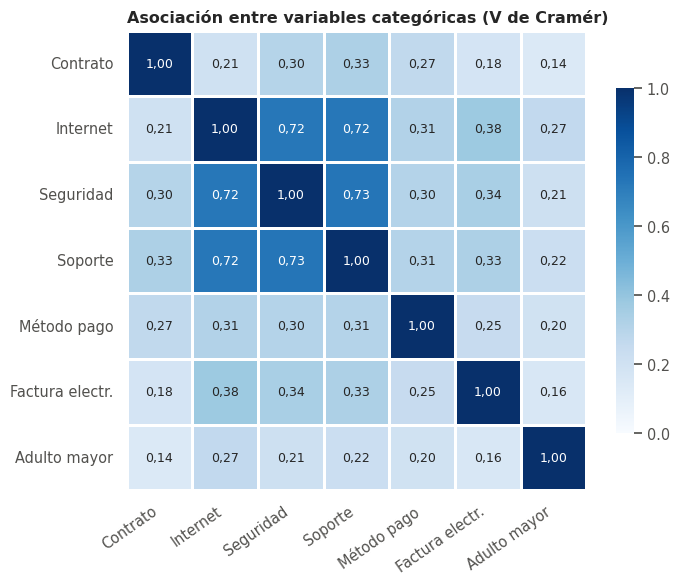

clientes  abandonos   tasa  ic_inf  ic_sup
                   TechSupport                                            
Soporte técnico    No               2230       1101  0.494   0.473   0.514
                   Sí                866        196  0.226   0.200   0.255
Seguridad en línea No               2257       1114  0.494   0.473   0.514
                   Sí                839        183  0.218   0.191   0.247

In [22]:
claves = ["Contract", "InternetService", "OnlineSecurity", "TechSupport", "PaymentMethod", "PaperlessBilling", "SeniorCitizen"]
cortas_cat = {"Contract": "Contrato", "InternetService": "Internet", "OnlineSecurity": "Seguridad",
              "TechSupport": "Soporte", "PaymentMethod": "Método pago", "PaperlessBilling": "Factura electr.",
              "SeniorCitizen": "Adulto mayor"}
fig, eje = plt.subplots(figsize=(7.5, 6))
graficar_mapa_calor(an.matriz_cramers_v(df, claves), "Asociación entre variables categóricas (V de Cramér)",
                    eje, cmap="Blues", vmin=0, vmax=1, etiquetas=cortas_cat)
fig.tight_layout()
mostrar_y_guardar(fig, "fig07_cramer_categoricas")

fibra = df[df["InternetService"] == "Fibra óptica"]
display(pd.concat({"Soporte técnico": an.tasa_abandono_por(fibra, "TechSupport").set_index("TechSupport"),
                   "Seguridad en línea": an.tasa_abandono_por(fibra, "OnlineSecurity").set_index("OnlineSecurity")})
        [["clientes", "abandonos", "tasa", "ic_inf", "ic_sup"]].round(3))

Seguridad en línea y soporte técnico tienen V ≈ 0,72 con el tipo de internet, en buena parte porque comparten la categoría "Sin servicio de internet". Eso obliga a revisar si su efecto sobre el abandono es real o solo refleja el tipo de conexión. Dentro de los clientes de fibra óptica la diferencia se mantiene: sin soporte técnico abandona el 49,4 % y con soporte el 22,6 %; sin seguridad en línea el 49,4 % y con ella el 21,8 %. El efecto protector de estos servicios no depende del tipo de internet.

### 4.7 Segmentos de mayor riesgo

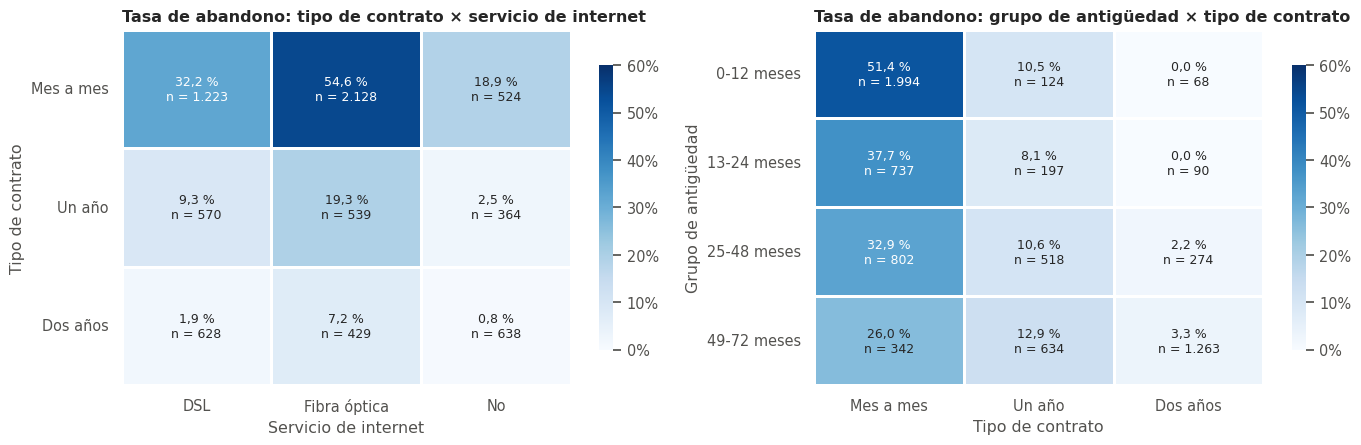

In [23]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))
graficar_segmentos(df, "Contract", "InternetService", ejes[0])
graficar_segmentos(df, "grupo_antiguedad", "Contract", ejes[1])
fig.tight_layout()
mostrar_y_guardar(fig, "fig08_segmentos")

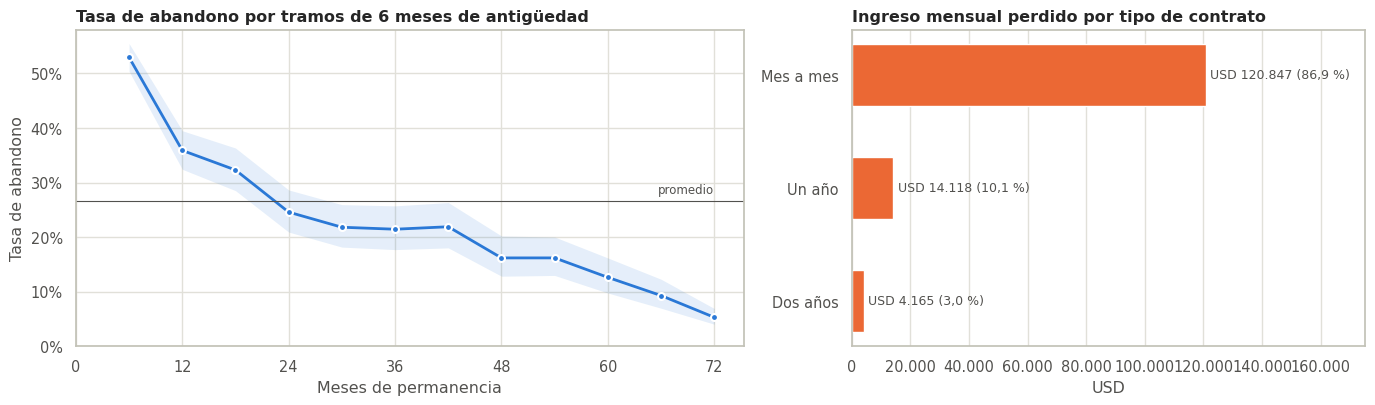

In [24]:
# Tasa de abandono mes a mes según antigüedad, con banda de confianza
bordes = np.arange(0, 78, 6)
tramos = df.groupby(pd.cut(df["tenure"], bordes, include_lowest=True), observed=True)["abandono"].agg(["sum", "count"])
tramos["tasa"] = tramos["sum"] / tramos["count"]
ic = np.array([an.intervalo_wilson(s, n) for s, n in zip(tramos["sum"], tramos["count"])])
meses = [int(i.right) for i in tramos.index]

fig, ejes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
ejes[0].fill_between(meses, ic[:, 0], ic[:, 1], color=AZUL, alpha=0.12, lw=0)
ejes[0].plot(meses, tramos["tasa"], color=AZUL, lw=2, marker="o", ms=5, mec="white", mew=1.5)
ejes[0].axhline(df["abandono"].mean(), color=TINTA_SEC, lw=0.8)
ejes[0].text(72, df["abandono"].mean() + 0.015, "promedio", ha="right", fontsize=8.5, color=TINTA_SEC)
ejes[0].set(title="Tasa de abandono por tramos de 6 meses de antigüedad", xlabel="Meses de permanencia",
            ylabel="Tasa de abandono", xticks=range(0, 73, 12), ylim=(0, None))
ejes[0].yaxis.set_major_formatter(PCT)

perdidos = df[df["abandono"] == 1]
ingreso = (perdidos.groupby("Contract")["MonthlyCharges"].sum()
           .reindex(pr.ORDEN_CATEGORIAS["Contract"]))
ejes[1].barh(ingreso.index, ingreso.values, color=NARANJA, height=0.55)
for yi, v in enumerate(ingreso.values):
    ejes[1].text(v + 1500, yi, f"USD {an.fmt_num(v)} ({an.fmt_pct(v / ingreso.sum())})", va="center",
                 fontsize=9, color=TINTA_SEC)
ejes[1].invert_yaxis()
ejes[1].set(title="Ingreso mensual perdido por tipo de contrato", xlabel="USD", xlim=(0, ingreso.max() * 1.45))
ejes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: an.fmt_num(v)))
ejes[1].grid(axis="y", visible=False)
fig.tight_layout()
mostrar_y_guardar(fig, "fig09_antiguedad_ingreso")

In [25]:
segmentos = {
    "Mes a mes + fibra óptica": (df["Contract"] == "Mes a mes") & (df["InternetService"] == "Fibra óptica"),
    "Mes a mes + fibra + cheque electrónico": (df["Contract"] == "Mes a mes") & (df["InternetService"] == "Fibra óptica")
                                              & (df["PaymentMethod"] == "Cheque electrónico"),
    "Mes a mes + 0-12 meses": (df["Contract"] == "Mes a mes") & (df["tenure"] <= 12),
    "Dos años + DSL": (df["Contract"] == "Dos años") & (df["InternetService"] == "DSL"),
}
filas = []
for nombre, mascara in segmentos.items():
    s = df[mascara]
    filas.append({"segmento": nombre, "clientes": len(s), "% de la base": 100 * len(s) / len(df),
                  "tasa_abandono_%": 100 * s["abandono"].mean(),
                  "% de los abandonos": 100 * s["abandono"].sum() / df["abandono"].sum(),
                  "p_binomial_vs_global": an.prueba_tasa_vs_global(s["abandono"].sum(), len(s), df["abandono"].mean())})
display(pd.DataFrame(filas).style.format({"% de la base": "{:.1f}", "tasa_abandono_%": "{:.1f}",
                                          "% de los abandonos": "{:.1f}", "p_binomial_vs_global": "{:.1e}"})
        .hide(axis="index"))
print("Participación de cada grupo de antigüedad en el total de abandonos:")
print((perdidos["grupo_antiguedad"].value_counts(normalize=True) * 100).round(1).reindex(pr.GRUPOS_ANTIGUEDAD))

segmento,clientes,% de la base,tasa_abandono_%,% de los abandonos,p_binomial_vs_global
Mes a mes + fibra óptica,2128,30.2,54.6,62.2,2.2e-164
Mes a mes + fibra + cheque electrónico,1307,18.6,60.4,42.2,4.9e-145
Mes a mes + 0-12 meses,1994,28.3,51.4,54.8,3.6e-122
Dos años + DSL,628,8.9,1.9,0.6,3.8e-65


Participación de cada grupo de antigüedad en el total de abandonos:
grupo_antiguedad
0-12 meses     55.5
13-24 meses    15.7
25-48 meses    17.4
49-72 meses    11.4
Name: proportion, dtype: float64


- La combinación **mes a mes + fibra óptica** reúne 2.128 clientes (30,2 % de la base) con una tasa de abandono de 54,6 %. Si además pagan con cheque electrónico, la tasa sube a 60,4 % en 1.307 clientes. En el otro extremo, contrato a dos años con DSL apenas llega a 1,9 %.
- El riesgo es muy alto al inicio: en los primeros seis meses la tasa supera el 50 % y cae por debajo del promedio alrededor del segundo año. Los clientes con 0-12 meses de antigüedad son el 55,5 % de todos los abandonos.
- El contrato pesa incluso con los años: un cliente mes a mes con más de cuatro años de antigüedad todavía abandona 26,0 %, mientras uno con contrato a dos años no pasa de 3,3 % en ningún grupo de antigüedad.
- En ingreso, los contratos mes a mes explican el 86,9 % de la facturación mensual perdida y la fibra óptica el 82,2 %.

Todas las diferencias de estos segmentos frente a la tasa global son significativas en la prueba binomial (p < 0,001).

### 4.8 Síntesis del EDA

| Hallazgo | Evidencia |
|---|---|
| El contrato mes a mes es el principal factor asociado al abandono | 42,7 % vs. 2,8 % en dos años; V = 0,41 |
| El primer año concentra el riesgo | 47,4 % de abandono en 0-12 meses; 55,5 % de todos los abandonos; r = −0,48 |
| La fibra óptica pierde clientes y dinero | 41,9 % de abandono; 82,2 % del ingreso perdido; mediana USD 91,68 |
| Soporte técnico y seguridad en línea protegen | Dentro de fibra: 49,4 % sin soporte vs. 22,6 % con soporte |
| Pagar con cheque electrónico se asocia a más abandono | 45,3 % vs. 15-17 % con pago automático |
| Género y telefonía no aportan | V < 0,02, no significativas |

## 5. Lógica del análisis automático

La pestaña *Análisis automático* del dashboard llama a `an.analisis_automatico(vista_filtrada, base_completa)`. La función recalcula las pruebas sobre los clientes que el usuario tenga filtrados y redacta los hallazgos en texto. Antes de probar, verifica que haya al menos 30 clientes y 10 casos en cada grupo; si no, avisa en lugar de mostrar resultados poco confiables.

Así se ve el resultado sobre la base completa, sobre un segmento y sobre una selección demasiado pequeña:

In [26]:
def imprimir_hallazgos(titulo, datos):
    resultado = an.analisis_automatico(datos, df)
    display(Markdown(f"**{titulo}**\n\n" + "\n".join(f"- {h}" for h in resultado["hallazgos"])))

imprimir_hallazgos("Base completa", df)
imprimir_hallazgos("Filtro: contrato mes a mes y fibra óptica",
                   df[(df["Contract"] == "Mes a mes") & (df["InternetService"] == "Fibra óptica")])
imprimir_hallazgos("Filtro: más de 60 meses y cargo menor a USD 30",
                   df[(df["tenure"] > 60) & (df["MonthlyCharges"] < 30)])

**Base completa**

- La base completa tiene 7.043 clientes y una tasa de abandono de 26,5 %.
- Los clientes que abandonaron representaban USD 139.131 de facturación mensual, el 30,5 % del ingreso de la selección.
- La variable más asociada al abandono es «Tipo de contrato» (V de Cramér = 0,41, efecto mediano): la tasa va de 2,8 % en «Dos años» a 42,7 % en «Mes a mes».
- Quienes abandonan tienen menor «Antigüedad (meses)»: mediana de 10,0 frente a 38,0 en quienes permanecen (Mann-Whitney, p < 0,001; r = -0,48).
- El segmento de mayor riesgo es «Grupo de antigüedad: 0-12 meses», con 47,4 % de abandono entre 2.186 clientes (IC 95 %: 45,4 % a 49,5 %).

**Filtro: contrato mes a mes y fibra óptica**

- La selección (2.128 clientes) tiene una tasa de abandono de 54,6 %, 28,1 puntos por encima del total. La diferencia es estadísticamente significativa (prueba binomial, p < 0,001).
- Los clientes que abandonaron representaban USD 100.482 de facturación mensual, el 54,3 % del ingreso de la selección.
- La variable más asociada al abandono es «Seguridad en línea» (V de Cramér = 0,16, efecto pequeño): la tasa va de 37,0 % en «Sí» a 58,1 % en «No».
- Quienes abandonan tienen menor «Antigüedad (meses)»: mediana de 10,0 frente a 24,5 en quienes permanecen (Mann-Whitney, p < 0,001; r = -0,37).
- El segmento de mayor riesgo es «Grupo de antigüedad: 0-12 meses», con 70,2 % de abandono entre 916 clientes (IC 95 %: 67,2 % a 73,1 %).

**Filtro: más de 60 meses y cargo menor a USD 30**

- La selección tiene 278 clientes y 1 abandono. Se necesitan al menos 30 clientes y 10 casos en cada grupo (abandona / permanece) para que las pruebas sean confiables; amplíe los filtros.

## 6. Arquitectura y código del dashboard

### 6.1 Arquitectura

```
 data/Telco-Customer-Churn.csv
               │
               ▼
      procesamiento.py ──► DataFrame limpio + bitácora   (se ejecuta una vez y queda en caché)
               │
       ┌───────┴────────┐
       ▼                ▼
  analisis.py       graficos.py
  (pruebas y        (figuras Plotly)
   hallazgos)
       └───────┬────────┘
               ▼
            app.py ── barra lateral de filtros ──► vista filtrada ──► pestañas
```

Cada vez que el usuario cambia un filtro, Streamlit vuelve a ejecutar `app.py`: toma los valores guardados en `st.session_state`, filtra la base y recalcula indicadores, gráficos y pruebas. La carga y limpieza está decorada con `@st.cache_data`, así que el CSV no se vuelve a procesar en cada interacción.

### 6.2 Librerías y justificación

| Librería | Uso en el proyecto | Por qué la elegimos |
|---|---|---|
| **Streamlit** | Interfaz web, filtros, pestañas, indicadores y caché | La aplicación se escribe solo en Python, sin HTML ni *callbacks*. Frente a Dash requiere menos código para un tablero de este tamaño y se publica gratis en Streamlit Community Cloud desde GitHub |
| **Plotly** | Gráficos interactivos del dashboard | Zoom, *hover* y selección por caja o lazo sin programar JavaScript. Streamlit devuelve a Python los puntos seleccionados (`on_select`), lo que permite analizar un grupo elegido a mano |
| **pandas / NumPy** | Manipulación y filtrado de datos | Estándar para datos tabulares; los filtros se aplican con máscaras booleanas |
| **SciPy** | Pruebas estadísticas | Chi-cuadrado, U de Mann-Whitney, Kruskal-Wallis, prueba binomial y D'Agostino-Pearson |
| **Matplotlib / Seaborn** | Gráficos estáticos del notebook y del reporte | Imágenes reproducibles que se exportan en PNG |

### 6.3 Contenido de la aplicación

| Pestaña | Qué muestra | Interactividad |
|---|---|---|
| Encabezado | Nombre del proyecto, descripción, integrantes y universidad; indicadores de clientes, tasa de abandono, clientes perdidos, ingreso en riesgo y antigüedad media, con la diferencia frente a la base total | Los indicadores se recalculan con los filtros |
| Resumen | Tasa por contrato y por método de pago (con IC 95 %), curva por antigüedad e ingreso perdido por tipo de internet | *Hover* con detalle, zoom |
| Exploración | Cualquier variable: distribución o tasa por categoría, con la prueba estadística correspondiente; dispersión antigüedad vs. cargo mensual | Selector de variable; selección por caja o lazo que calcula indicadores del grupo elegido |
| Segmentos | Mapa de calor de dos variables a elección y ranking de segmentos críticos | Selectores de filas y columnas; tamaño mínimo del segmento |
| Análisis automático | Hallazgos redactados, V de Cramér, correlación de Spearman, descriptivos, chi-cuadrado y Mann-Whitney | Todo se recalcula para la selección |
| Vista previa | Primeros registros, estructura del dataset (tipo, no nulos, valores únicos) y resumen estadístico | Descarga de la selección en CSV |
| Calidad de datos | Bitácora de limpieza, diagnóstico del crudo y atípicos | Consulta |

Filtros de la barra lateral: tipo de contrato, servicio de internet, método de pago, soporte técnico, adulto mayor, rango de antigüedad y rango de cargo mensual, más un botón para restablecerlos.

### 6.4 Código de los módulos del dashboard

In [27]:
%%writefile telco_dashboard/graficos.py
"""
graficos.py
-----------
Figuras interactivas (Plotly) del dashboard. Todas usan el mismo estilo:
fondo claro, líneas de guía tenues y dos colores fijos para identificar
a los clientes que permanecen (azul) y a los que abandonan (naranja).
"""

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from analisis import fmt_num, fmt_pct, intervalo_wilson, tasa_abandono_por
from procesamiento import ORDEN_CATEGORIAS, etiqueta

# Paleta validada para daltonismo (azul / naranja) y tonos neutros
AZUL = "#2a78d6"
NARANJA = "#eb6834"
GRIS = "#c3c2b7"
TINTA = "#0b0b0b"
TINTA_SECUNDARIA = "#52514e"
TINTA_TENUE = "#898781"
GUIA = "#e1e0d9"
FONDO = "#fcfcfb"
COLORES_CHURN = {"No": AZUL, "Sí": NARANJA}
NOMBRES_CHURN = {"No": "Permanece", "Sí": "Abandona"}
ESCALA_SECUENCIAL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
ESCALA_DIVERGENTE = [[0, "#1c5cab"], [0.5, "#f0efec"], [1, "#c23a39"]]


def _estilo(fig, titulo=None, alto=360, leyenda=True):
    """Aplica el formato común a todas las figuras."""
    fig.update_layout(
        title=dict(text=titulo, x=0, xanchor="left", y=0.98, yanchor="top", yref="container",
                   font=dict(size=15, color=TINTA)) if titulo else None,
        height=alto,
        template="plotly_white",
        paper_bgcolor=FONDO,
        plot_bgcolor=FONDO,
        font=dict(family="system-ui, -apple-system, 'Segoe UI', sans-serif", size=12, color=TINTA_SECUNDARIA),
        margin=dict(l=10, r=20, t=(88 if leyenda else 60) if titulo else 30, b=10),
        separators=",.",
        showlegend=leyenda,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0, title=None),
        hoverlabel=dict(bgcolor="white", bordercolor=GUIA, font=dict(color=TINTA, size=12)),
        barcornerradius=4,
    )
    fig.update_xaxes(showgrid=True, gridcolor=GUIA, gridwidth=1, zeroline=False,
                     linecolor=GRIS, tickfont=dict(color=TINTA_TENUE))
    fig.update_yaxes(showgrid=True, gridcolor=GUIA, gridwidth=1, zeroline=False,
                     linecolor=GRIS, tickfont=dict(color=TINTA_TENUE))
    return fig


def _orden(col, valores):
    """Respeta el orden lógico si existe; si no, deja el orden recibido."""
    if col in ORDEN_CATEGORIAS:
        return [v for v in ORDEN_CATEGORIAS[col] if v in set(valores)]
    return list(valores)


def _espacio_barras(alto, n_barras, grosor=24):
    """Calcula el bargap para que cada barra quede de ~24 px sin importar la altura."""
    espacio_por_barra = (alto - 100) / max(n_barras, 1)
    return float(min(0.8, max(0.3, 1 - grosor / espacio_por_barra)))


def figura_vacia(mensaje="No hay datos para los filtros seleccionados"):
    fig = go.Figure()
    fig.add_annotation(text=mensaje, showarrow=False, font=dict(size=14, color=TINTA_TENUE))
    fig.update_xaxes(visible=False)
    fig.update_yaxes(visible=False)
    return _estilo(fig, alto=260, leyenda=False)


# ---------------------------------------------------------------------------
# Tasa de abandono
# ---------------------------------------------------------------------------
def tasa_por_categoria(df, col, tasa_global=None, titulo=None, alto=None):
    """Barras horizontales con la tasa de abandono por categoría e IC 95 %."""
    if df.empty:
        return figura_vacia()
    tabla = tasa_abandono_por(df, col)
    if col in ORDEN_CATEGORIAS:
        tabla[col] = pd.Categorical(tabla[col], _orden(col, tabla[col]), ordered=True)
        tabla = tabla.sort_values(col, ascending=False)
    elif pd.api.types.is_numeric_dtype(tabla[col]):
        tabla = tabla.sort_values(col, ascending=False)
    else:
        tabla = tabla.sort_values("tasa")
    tabla[col] = tabla[col].astype(str)

    fig = go.Figure(go.Bar(
        x=tabla["tasa"], y=tabla[col], orientation="h",
        marker=dict(color=AZUL),
        error_x=dict(type="data", symmetric=False,
                     array=tabla["ic_sup"] - tabla["tasa"],
                     arrayminus=tabla["tasa"] - tabla["ic_inf"],
                     color=TINTA_TENUE, thickness=1, width=4),
        customdata=np.column_stack([tabla["clientes"], tabla["abandonos"], tabla["ic_inf"], tabla["ic_sup"]]),
        hovertemplate=(
            "<b>%{y}</b><br>Tasa de abandono: %{x:.1%}"
            "<br>IC 95 %: %{customdata[2]:.1%} – %{customdata[3]:.1%}"
            "<br>Clientes: %{customdata[0]:,.0f}<br>Abandonos: %{customdata[1]:,.0f}<extra></extra>"
        ),
    ))
    # Etiqueta de valor después del intervalo, para que no se monte sobre la barra de error
    fig.add_trace(go.Scatter(
        x=tabla["ic_sup"], y=tabla[col], mode="text", text=[fmt_pct(t) for t in tabla["tasa"]],
        textposition="middle right", textfont=dict(color=TINTA_SECUNDARIA, size=12),
        hoverinfo="skip", cliponaxis=False,
    ))
    if tasa_global is not None:
        fig.add_vline(x=tasa_global, line_width=1, line_color=TINTA_TENUE,
                      annotation_text=f"Promedio {fmt_pct(tasa_global)}",
                      annotation_position="top", annotation_font=dict(color=TINTA_TENUE, size=11))
    alto = alto or max(240, 110 + 46 * len(tabla))
    _estilo(fig, titulo or f"Tasa de abandono por {etiqueta(col).lower()}", alto=alto, leyenda=False)
    fig.update_layout(bargap=_espacio_barras(alto, len(tabla)))
    fig.update_xaxes(tickformat=".0%", rangemode="tozero",
                     range=[0, min(1, float(tabla["ic_sup"].max()) * 1.25 + 0.02)])
    fig.update_yaxes(showgrid=False, tickfont=dict(color=TINTA_SECUNDARIA))
    return fig


def tasa_por_antiguedad(df, paso=6, tasa_global=None):
    """Línea de la tasa de abandono según los meses de permanencia, con banda IC 95 %."""
    if df.empty:
        return figura_vacia()
    bordes = np.arange(0, 72 + paso, paso)
    grupos = pd.cut(df["tenure"], bins=bordes, include_lowest=True)
    tabla = df.groupby(grupos, observed=True)["abandono"].agg(clientes="count", abandonos="sum").reset_index()
    tabla = tabla[tabla["clientes"] > 0]
    tabla["tasa"] = tabla["abandonos"] / tabla["clientes"]
    ic = np.array([intervalo_wilson(a, n) for a, n in zip(tabla["abandonos"], tabla["clientes"])])
    tabla["mes"] = [int(i.right) for i in tabla["tenure"]]
    tabla["rango"] = [f"{max(int(np.ceil(i.left)), 0)}–{int(i.right)} meses" for i in tabla["tenure"]]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=np.concatenate([tabla["mes"], tabla["mes"][::-1]]),
        y=np.concatenate([ic[:, 1], ic[:, 0][::-1]]),
        fill="toself", fillcolor="rgba(42,120,214,0.10)", line=dict(width=0),
        hoverinfo="skip", showlegend=False,
    ))
    fig.add_trace(go.Scatter(
        x=tabla["mes"], y=tabla["tasa"], mode="lines+markers",
        line=dict(color=AZUL, width=2),
        marker=dict(size=8, color=AZUL, line=dict(color=FONDO, width=2)),
        customdata=np.column_stack([tabla["rango"], tabla["clientes"], ic[:, 0], ic[:, 1]]),
        hovertemplate=("<b>%{customdata[0]}</b><br>Tasa de abandono: %{y:.1%}"
                       "<br>Clientes: %{customdata[1]}<extra></extra>"),
        showlegend=False,
    ))
    if tasa_global is not None:
        fig.add_hline(y=tasa_global, line_width=1, line_color=TINTA_TENUE,
                      annotation_text=f"Promedio {fmt_pct(tasa_global)}",
                      annotation_position="top right", annotation_font=dict(color=TINTA_TENUE, size=11))
    _estilo(fig, "Tasa de abandono según la antigüedad del cliente", alto=360, leyenda=False)
    fig.update_xaxes(title="Meses de permanencia", dtick=12, range=[0, 74])
    fig.update_yaxes(tickformat=".0%", rangemode="tozero")
    fig.update_layout(hovermode="x")
    return fig


def ingreso_en_riesgo(df, col, alto=None):
    """Facturación mensual de los clientes que abandonaron, por categoría."""
    perdidos = df[df["abandono"] == 1]
    if perdidos.empty:
        return figura_vacia("No hay abandonos en la selección")
    tabla = perdidos.groupby(col, observed=True)["MonthlyCharges"].agg(["sum", "count"]).reset_index()
    tabla = tabla.sort_values("sum")
    tabla[col] = tabla[col].astype(str)
    fig = go.Figure(go.Bar(
        x=tabla["sum"], y=tabla[col], orientation="h", marker=dict(color=NARANJA),
        text=[f"USD {fmt_num(v)}" for v in tabla["sum"]],
        textposition="outside", cliponaxis=False, textfont=dict(color=TINTA_SECUNDARIA),
        customdata=tabla["count"],
        hovertemplate="<b>%{y}</b><br>Ingreso mensual perdido: USD %{x:,.0f}<br>Clientes perdidos: %{customdata}<extra></extra>",
    ))
    _estilo(fig, f"Ingreso mensual perdido por {etiqueta(col).lower()}",
            alto=alto or max(240, 110 + 46 * len(tabla)), leyenda=False)
    fig.update_layout(bargap=_espacio_barras(alto or max(240, 110 + 46 * len(tabla)), len(tabla)))
    fig.update_xaxes(tickprefix="USD ", range=[0, tabla["sum"].max() * 1.3])
    fig.update_yaxes(showgrid=False, tickfont=dict(color=TINTA_SECUNDARIA))
    return fig


# ---------------------------------------------------------------------------
# Distribuciones y relaciones
# ---------------------------------------------------------------------------
def distribucion_numerica(df, col):
    """Histograma superpuesto (porcentaje dentro de cada grupo) con caja marginal."""
    if df.empty:
        return figura_vacia()
    datos = df.assign(Estado=df["Churn"].map(NOMBRES_CHURN))
    fig = px.histogram(
        datos, x=col, color="Estado", marginal="box", barmode="overlay",
        histnorm="percent", nbins=36, opacity=0.6,
        color_discrete_map={"Permanece": AZUL, "Abandona": NARANJA},
        category_orders={"Estado": ["Permanece", "Abandona"]},
        labels={col: etiqueta(col)},
    )
    fig.update_traces(hovertemplate="%{x}<br>%{y:.1f} % del grupo<extra></extra>", selector=dict(type="histogram"))
    _estilo(fig, f"Distribución de {etiqueta(col).lower()} según abandono", alto=420)
    fig.update_yaxes(title="% de clientes del grupo", row=1, col=1)
    fig.update_layout(bargap=0.04)
    return fig


def dispersion_antiguedad_cargo(df):
    """Dispersión antigüedad vs. cargo mensual; admite selección por caja o lazo."""
    if df.empty:
        return figura_vacia()
    fig = go.Figure()
    for valor in ["No", "Sí"]:
        parte = df[df["Churn"] == valor]
        fig.add_trace(go.Scattergl(
            x=parte["tenure"], y=parte["MonthlyCharges"], mode="markers",
            name=NOMBRES_CHURN[valor],
            marker=dict(size=7, color=COLORES_CHURN[valor], opacity=0.55, line=dict(width=0.5, color=FONDO)),
            customdata=np.column_stack([parte["customerID"], parte["Contract"], parte["InternetService"]]),
            hovertemplate=("<b>%{customdata[0]}</b><br>Antigüedad: %{x} meses"
                           "<br>Cargo mensual: USD %{y:.2f}<br>Contrato: %{customdata[1]}"
                           "<br>Internet: %{customdata[2]}<extra></extra>"),
        ))
    _estilo(fig, "Antigüedad frente a cargo mensual (seleccione una zona con caja o lazo)", alto=440)
    fig.update_xaxes(title="Antigüedad (meses)")
    fig.update_yaxes(title="Cargo mensual (USD)")
    fig.update_layout(dragmode="select")
    return fig


def mapa_calor_segmentos(df, fila, columna):
    """Tasa de abandono cruzando dos variables categóricas."""
    if df.empty:
        return figura_vacia()
    tabla = df.groupby([fila, columna], observed=True)["abandono"].agg(["mean", "count"]).reset_index()
    tasas = tabla.pivot(index=fila, columns=columna, values="mean")
    conteos = tabla.pivot(index=fila, columns=columna, values="count")
    tasas = tasas.reindex(index=_orden(fila, tasas.index), columns=_orden(columna, tasas.columns))
    conteos = conteos.reindex(index=tasas.index, columns=tasas.columns)
    texto = [[f"{fmt_pct(t)}<br>n = {fmt_num(c)}" if pd.notna(c) else "" for t, c in zip(ft, fc)]
             for ft, fc in zip(tasas.to_numpy(), conteos.to_numpy())]
    fig = go.Figure(go.Heatmap(
        z=tasas.to_numpy(), x=[str(c) for c in tasas.columns], y=[str(i) for i in tasas.index],
        text=texto, texttemplate="%{text}", textfont=dict(size=12),
        colorscale=ESCALA_SECUENCIAL, zmin=0, zmax=max(0.6, float(np.nanmax(tasas.to_numpy()))),
        xgap=2, ygap=2, customdata=conteos.to_numpy(),
        hovertemplate=(f"{etiqueta(fila)}: %{{y}}<br>{etiqueta(columna)}: %{{x}}"
                       "<br>Tasa de abandono: %{z:.1%}<br>Clientes: %{customdata}<extra></extra>"),
        colorbar=dict(title=dict(text="Tasa", side="top"), tickformat=".0%", thickness=12, outlinewidth=0),
    ))
    _estilo(fig, f"Tasa de abandono: {etiqueta(fila).lower()} × {etiqueta(columna).lower()}",
            alto=max(320, 140 + 70 * len(tasas.index)), leyenda=False)
    fig.update_xaxes(showgrid=False, title=etiqueta(columna), side="bottom")
    fig.update_yaxes(showgrid=False, title=etiqueta(fila), autorange="reversed")
    return fig


# ---------------------------------------------------------------------------
# Resultados estadísticos
# ---------------------------------------------------------------------------
def ranking_asociacion(tabla_chi):
    """V de Cramér por variable; en gris las asociaciones no significativas."""
    if tabla_chi is None or tabla_chi.empty:
        return figura_vacia("No fue posible calcular las pruebas")
    tabla = tabla_chi.sort_values("v_cramer")
    fig = go.Figure()
    for estado, color, nombre in [("Sí", AZUL, "Significativa (Bonferroni)"), ("No", GRIS, "No significativa")]:
        parte = tabla[tabla["significativa"] == estado]
        if parte.empty:
            continue
        fig.add_trace(go.Bar(
            x=parte["v_cramer"], y=parte["nombre"], orientation="h", name=nombre,
            marker=dict(color=color),
            customdata=np.column_stack([parte["chi2"], parte["p_bonferroni"], parte["efecto"]]),
            hovertemplate=("<b>%{y}</b><br>V de Cramér: %{x:.3f}<br>χ²: %{customdata[0]}"
                           "<br>p ajustado: %{customdata[1]:.2e}<br>Efecto: %{customdata[2]}<extra></extra>"),
        ))
    _estilo(fig, "Fuerza de asociación con el abandono (V de Cramér)", alto=max(300, 90 + 26 * len(tabla)))
    fig.update_layout(bargap=0.35, barmode="overlay")
    fig.update_yaxes(showgrid=False, categoryorder="array", categoryarray=tabla["nombre"].tolist(),
                     tickfont=dict(color=TINTA_SECUNDARIA))
    for x, texto in [(0.1, "pequeño"), (0.3, "mediano")]:
        fig.add_vline(x=x, line_width=1, line_color=GRIS, layer="below", annotation_text=texto,
                      annotation_position="bottom right", annotation_font=dict(color=TINTA_TENUE, size=10))
    return fig


ETIQUETAS_CORTAS = {"tenure": "Antigüedad", "MonthlyCharges": "Cargo mensual", "TotalCharges": "Cargo total",
                    "num_servicios": "N.º servicios", "abandono": "Abandono"}


def mapa_correlacion(matriz, titulo="Correlación de Spearman"):
    etiquetas = [ETIQUETAS_CORTAS.get(c, etiqueta(c)) for c in matriz.columns]
    fig = go.Figure(go.Heatmap(
        z=matriz.to_numpy(), x=etiquetas, y=etiquetas,
        text=np.vectorize(lambda v: f"{v:.2f}".replace(".", ","))(matriz.to_numpy()),
        texttemplate="%{text}", colorscale=ESCALA_DIVERGENTE, zmin=-1, zmax=1, xgap=2, ygap=2,
        hovertemplate="%{y} · %{x}<br>ρ = %{z:.3f}<extra></extra>",
        colorbar=dict(thickness=12, outlinewidth=0),
    ))
    _estilo(fig, titulo, alto=430, leyenda=False)
    fig.update_xaxes(showgrid=False, tickangle=-30, side="bottom")
    fig.update_yaxes(showgrid=False, autorange="reversed")
    return fig

Writing telco_dashboard/graficos.py


In [28]:
%%writefile telco_dashboard/app.py
"""
app.py
------
Dashboard analítico de abandono de clientes (Telco Customer Churn).

Ejecución local:   streamlit run app.py
Publicación:       Streamlit Community Cloud (ver README.md)
"""

import pandas as pd
import streamlit as st

import analisis as an
import graficos as gr
import procesamiento as pr
from analisis import fmt_num, fmt_pct

st.set_page_config(
    page_title="Abandono de clientes · Telco",
    page_icon=":material/insights:",
    layout="wide",
)

st.markdown(
    """
    <style>
      .block-container {padding-top: 2.2rem; padding-bottom: 2rem;}
      [data-testid="stMetricValue"] {font-size: 1.7rem;}
      .equipo {color: #52514e; font-size: .92rem; margin: -.6rem 0 .2rem 0; line-height: 1.55;}
      .hallazgo {padding: .75rem 1rem; border-left: 3px solid #2a78d6; background: #f3f2ee;
                 border-radius: 4px; margin-bottom: .6rem; line-height: 1.5;}
    </style>
    """,
    unsafe_allow_html=True,
)

CONFIG_GRAFICO = {"displaylogo": False, "modeBarButtonsToRemove": ["toImage"]}
INTEGRANTES = ["Bonny Darhyll Brayan Galindo Santos", "Andrés Alberto López Herrera", "Camilo José Rodríguez Ayubi"]
FILTROS_CATEGORICOS = ["Contract", "InternetService", "PaymentMethod", "TechSupport", "SeniorCitizen"]
VARIABLES_CATEGORICAS = pr.COLS_CATEGORICAS + ["grupo_antiguedad", "pago_automatico", "num_servicios"]


# ---------------------------------------------------------------------------
# Datos
# ---------------------------------------------------------------------------
@st.cache_data(show_spinner="Cargando y limpiando los datos…")
def obtener_datos():
    crudo = pr.cargar_datos()
    limpio, bitacora = pr.preparar_datos(crudo)
    return crudo, limpio, bitacora


def opciones(df, col):
    valores = df[col].unique().tolist()
    if col in pr.ORDEN_CATEGORIAS:
        return [v for v in pr.ORDEN_CATEGORIAS[col] if v in valores]
    return sorted(valores)


crudo, df, bitacora = obtener_datos()
CARGO_MIN, CARGO_MAX = int(df["MonthlyCharges"].min()), int(df["MonthlyCharges"].max()) + 1
TASA_GLOBAL = df["abandono"].mean()


# ---------------------------------------------------------------------------
# Filtros (barra lateral)
# ---------------------------------------------------------------------------
def valores_por_defecto():
    for col in FILTROS_CATEGORICOS:
        st.session_state[f"f_{col}"] = []
    st.session_state["f_tenure"] = (0, 72)
    st.session_state["f_cargo"] = (CARGO_MIN, CARGO_MAX)


if "f_tenure" not in st.session_state:
    valores_por_defecto()

with st.sidebar:
    st.markdown("### :material/filter_alt: Filtros")
    st.caption("Todos los gráficos se recalculan con la selección. Un filtro vacío incluye todas las opciones.")
    for col in FILTROS_CATEGORICOS:
        st.multiselect(pr.etiqueta(col), opciones(df, col), key=f"f_{col}", placeholder="Todas")
    st.slider("Antigüedad (meses)", 0, 72, key="f_tenure")
    st.slider("Cargo mensual (USD)", CARGO_MIN, CARGO_MAX, key="f_cargo")
    st.button("Restablecer filtros", icon=":material/restart_alt:", on_click=valores_por_defecto, width="stretch")
    st.divider()
    st.caption(
        "**Fuente:** IBM Telco Customer Churn (Kaggle).  \n"
        "**Docente:** Hamilton Rivera"
    )


def aplicar_filtros(datos):
    mascara = pd.Series(True, index=datos.index)
    for col in FILTROS_CATEGORICOS:
        seleccion = st.session_state[f"f_{col}"]
        if seleccion:
            mascara &= datos[col].isin(seleccion)
    t_min, t_max = st.session_state["f_tenure"]
    c_min, c_max = st.session_state["f_cargo"]
    mascara &= datos["tenure"].between(t_min, t_max)
    mascara &= datos["MonthlyCharges"].between(c_min, c_max)
    return datos.loc[mascara]


dff = aplicar_filtros(df)


# ---------------------------------------------------------------------------
# Encabezado e indicadores
# ---------------------------------------------------------------------------
st.title("Abandono de clientes en telecomunicaciones")
st.markdown(
    "<div class='equipo'>Análisis del abandono (<i>churn</i>) de clientes con filtros, gráficos interactivos "
    "y pruebas estadísticas.<br>"
    f"<b>Integrantes:</b> {' · '.join(INTEGRANTES)}<br>"
    "Especialización en Inteligencia Artificial · Corporación Unificada Nacional de Educación Superior (CUN) · "
    "Programación para Analítica de Datos e IA</div>",
    unsafe_allow_html=True,
)
st.caption(
    f"Mostrando **{fmt_num(len(dff))}** de {fmt_num(len(df))} clientes "
    f"({fmt_pct(len(dff) / len(df))} de la base)."
)

if dff.empty:
    st.warning("Ningún cliente cumple con los filtros seleccionados. Amplíe la selección o restablezca los filtros.",
               icon=":material/search_off:")
    st.stop()

k_sel, k_tot = an.kpis(dff), an.kpis(df)
HAY_FILTRO = len(dff) < len(df)


def delta_puntos(valor, referencia="total"):
    if not HAY_FILTRO and referencia == "total":
        return None
    return f"{valor:+.1f}".replace(".", ",") + f" pp vs. {referencia}"


c1, c2, c3, c4, c5 = st.columns(5)
c1.metric("Clientes", fmt_num(k_sel["clientes"]), border=True,
          help="Clientes que cumplen con los filtros activos.")
c2.metric("Tasa de abandono", fmt_pct(k_sel["tasa"]), delta_puntos(100 * (k_sel["tasa"] - k_tot["tasa"])),
          delta_color="inverse", border=True, help="Porcentaje de clientes que se retiraron en el último mes.")
c3.metric("Clientes perdidos", fmt_num(k_sel["abandonos"]), border=True)
c4.metric("Ingreso en riesgo", f"USD {fmt_num(k_sel['ingreso_en_riesgo'])}",
          f"{fmt_pct(k_sel['ingreso_en_riesgo'] / k_sel['ingreso_mensual'])} del ingreso",
          delta_color="off", delta_arrow="off", border=True,
          help="Facturación mensual de los clientes que abandonaron y su peso sobre el ingreso de la vista.")
c5.metric("Antigüedad media", f"{fmt_num(k_sel['antiguedad_media'], 1)} meses",
          f"{k_sel['antiguedad_media'] - k_tot['antiguedad_media']:+.1f}".replace(".", ",") + " meses vs. total"
          if HAY_FILTRO else None,
          border=True)

tab_resumen, tab_explorar, tab_segmentos, tab_auto, tab_vista, tab_calidad = st.tabs([
    ":material/dashboard: Resumen",
    ":material/query_stats: Exploración",
    ":material/grid_view: Segmentos",
    ":material/auto_awesome: Análisis automático",
    ":material/table_view: Vista previa",
    ":material/cleaning_services: Calidad de datos",
])


def mostrar(fig, key, **kwargs):
    """Muestra una figura Plotly con el estilo propio (sin el tema de Streamlit)."""
    return st.plotly_chart(fig, key=key, theme=None, config=CONFIG_GRAFICO, **kwargs)


# ---------------------------------------------------------------------------
# Resumen
# ---------------------------------------------------------------------------
with tab_resumen:
    izq, der = st.columns(2)
    with izq, st.container(border=True):
        mostrar(gr.tasa_por_categoria(dff, "Contract", TASA_GLOBAL, alto=360), "res_contrato")
    with der, st.container(border=True):
        mostrar(gr.tasa_por_antiguedad(dff, paso=6, tasa_global=TASA_GLOBAL), "res_antiguedad")
    izq, der = st.columns(2)
    with izq, st.container(border=True):
        mostrar(gr.tasa_por_categoria(dff, "PaymentMethod", TASA_GLOBAL, alto=340), "res_pago")
    with der, st.container(border=True):
        mostrar(gr.ingreso_en_riesgo(dff, "InternetService", alto=340), "res_ingreso")
    st.caption("Las barras de error muestran el intervalo de confianza del 95 % (Wilson). "
               "La línea gris marca la tasa de abandono de toda la base.")


# ---------------------------------------------------------------------------
# Exploración
# ---------------------------------------------------------------------------
with tab_explorar:
    variables = {pr.etiqueta(c): c for c in pr.COLS_NUMERICAS + VARIABLES_CATEGORICAS}
    nombre = st.selectbox("Variable a explorar", list(variables), index=0)
    var = variables[nombre]

    grafico, detalle = st.columns([3, 2])
    if var in pr.COLS_NUMERICAS:
        with grafico, st.container(border=True):
            mostrar(gr.distribucion_numerica(dff, var), "exp_numerica")
        with detalle:
            st.markdown(f"**{nombre}: permanece vs. abandona**")
            resumen = (dff.groupby("Churn")[var].agg(["count", "mean", "median", "std"])
                       .rename(index={"No": "Permanece", "Sí": "Abandona"}).rename_axis("Grupo")
                       .rename(columns={"count": "Clientes", "mean": "Media", "median": "Mediana", "std": "Desv. est."}))
            st.dataframe(resumen.round(2), width="stretch")
            if dff["abandono"].nunique() == 2 and min(dff["abandono"].value_counts()) >= 10:
                mw = an.comparar_numericas(dff, [var]).iloc[0]
                conclusion = "hay" if mw["p_valor"] < an.ALFA else "no hay"
                st.info(f"Prueba U de Mann-Whitney: p {an.formato_p(mw['p_valor'])}, "
                        f"r = {fmt_num(mw['r_biserial'], 2)} (efecto {mw['efecto'].lower()}). "
                        f"Con 95 % de confianza, {conclusion} diferencia entre ambos grupos.",
                        icon=":material/functions:")
    else:
        with grafico, st.container(border=True):
            mostrar(gr.tasa_por_categoria(dff, var, TASA_GLOBAL), "exp_categorica")
        with detalle:
            st.markdown(f"**{nombre}: detalle por categoría**")
            tabla = an.tasa_abandono_por(dff, var)
            st.dataframe(
                tabla[[var, "clientes", "abandonos", "tasa", "participacion"]],
                hide_index=True, width="stretch",
                column_config={
                    var: st.column_config.TextColumn(nombre),
                    "clientes": st.column_config.NumberColumn("Clientes"),
                    "abandonos": st.column_config.NumberColumn("Abandonos"),
                    "tasa": st.column_config.ProgressColumn("Tasa de abandono", format="percent", min_value=0, max_value=1),
                    "participacion": st.column_config.NumberColumn("% de clientes", format="percent"),
                },
            )
            chi = an.pruebas_chi_cuadrado(dff, [var])
            if not chi.empty:
                fila = chi.iloc[0]
                conclusion = "depende" if fila["p_valor"] < an.ALFA else "no depende"
                st.info(f"Chi-cuadrado: χ² = {fmt_num(fila['chi2'], 1)}, gl = {fila['gl']}, "
                        f"p {an.formato_p(fila['p_valor'])}, V de Cramér = {fmt_num(fila['v_cramer'], 2)}. "
                        f"El abandono {conclusion} de esta variable (α = 0,05).",
                        icon=":material/functions:")

    st.markdown("#### Selección interactiva de clientes")
    st.caption("Arrastre sobre el gráfico (caja o lazo) para analizar un grupo; doble clic para quitar la selección.")
    with st.container(border=True):
        evento = mostrar(gr.dispersion_antiguedad_cargo(dff), "exp_dispersion",
                         on_select="rerun", selection_mode=("box", "lasso"))
    puntos = evento.selection.points if evento and evento.selection else []
    ids = {p["customdata"][0] for p in puntos if p.get("customdata")}
    if ids:
        grupo = dff[dff["customerID"].isin(ids)]
        k_grupo = an.kpis(grupo)
        s1, s2, s3, s4 = st.columns(4)
        s1.metric("Clientes seleccionados", fmt_num(k_grupo["clientes"]))
        s2.metric("Tasa de abandono", fmt_pct(k_grupo["tasa"]),
                  f"{100 * (k_grupo['tasa'] - k_sel['tasa']):+.1f}".replace(".", ",") + " pp vs. filtro actual",
                  delta_color="inverse")
        s3.metric("Cargo mensual medio", f"USD {fmt_num(grupo['MonthlyCharges'].mean(), 2)}")
        s4.metric("Contrato más común", grupo["Contract"].mode().iloc[0])
    else:
        st.caption(":material/touch_app: Aún no hay clientes seleccionados.")


# ---------------------------------------------------------------------------
# Segmentos
# ---------------------------------------------------------------------------
with tab_segmentos:
    categoricas = {pr.etiqueta(c): c for c in VARIABLES_CATEGORICAS}
    nombres = list(categoricas)
    a, b = st.columns(2)
    fila = a.selectbox("Variable en filas", nombres, index=nombres.index(pr.etiqueta("Contract")))
    columna = b.selectbox("Variable en columnas", nombres, index=nombres.index(pr.etiqueta("InternetService")))
    with st.container(border=True):
        if fila == columna:
            st.info("Elija dos variables distintas para cruzarlas.")
        else:
            mostrar(gr.mapa_calor_segmentos(dff, categoricas[fila], categoricas[columna]), "seg_mapa")

    st.markdown("#### Segmentos con mayor tasa de abandono")
    minimo = st.slider("Tamaño mínimo del segmento (clientes)", 10, 500, 100, step=10,
                       help="Evita que grupos muy pequeños aparezcan arriba solo por azar.")
    top = an.segmentos_criticos(dff, min_clientes=minimo, top=10)
    if top.empty:
        st.info("No hay segmentos con ese tamaño mínimo en la selección actual.")
    else:
        st.dataframe(
            top[["variable", "categoria", "clientes", "abandonos", "tasa", "ic_inf", "ic_sup"]],
            hide_index=True, width="stretch",
            column_config={
                "variable": "Variable", "categoria": "Categoría",
                "clientes": st.column_config.NumberColumn("Clientes"),
                "abandonos": st.column_config.NumberColumn("Abandonos"),
                "tasa": st.column_config.ProgressColumn("Tasa de abandono", format="percent", min_value=0, max_value=1),
                "ic_inf": st.column_config.NumberColumn("IC 95 % inferior", format="percent"),
                "ic_sup": st.column_config.NumberColumn("IC 95 % superior", format="percent"),
            },
        )


# ---------------------------------------------------------------------------
# Análisis automático
# ---------------------------------------------------------------------------
with tab_auto:
    resultado = an.analisis_automatico(dff, df)
    st.markdown("#### :material/auto_awesome: Hallazgos de la selección actual")
    for texto in resultado["hallazgos"]:
        st.markdown(f"<div class='hallazgo'>{texto}</div>", unsafe_allow_html=True)

    if resultado["suficiente"]:
        izq, der = st.columns(2)
        with izq, st.container(border=True):
            mostrar(gr.ranking_asociacion(resultado["chi_cuadrado"]), "auto_ranking")
        with der, st.container(border=True):
            mostrar(gr.mapa_correlacion(an.matriz_correlacion(dff), "Correlación de Spearman"), "auto_correlacion")

        with st.expander("Estadísticos descriptivos", icon=":material/table_chart:"):
            desc = resultado["descriptivos"].rename(index=pr.etiqueta)
            st.dataframe(desc, width="stretch")
        with st.expander("Pruebas chi-cuadrado (variables categóricas)", icon=":material/functions:"):
            st.dataframe(
                resultado["chi_cuadrado"].drop(columns="variable"), hide_index=True, width="stretch",
                column_config={"nombre": "Variable", "p_valor": st.column_config.NumberColumn("p", format="%.2e"),
                               "p_bonferroni": st.column_config.NumberColumn("p Bonferroni", format="%.2e"),
                               "v_cramer": "V de Cramér", "esperadas_>=5_%": "% esperadas ≥ 5"},
            )
        with st.expander("Pruebas U de Mann-Whitney (variables numéricas)", icon=":material/functions:"):
            st.dataframe(
                resultado["mann_whitney"].drop(columns="variable"), hide_index=True, width="stretch",
                column_config={"nombre": "Variable", "p_valor": st.column_config.NumberColumn("p", format="%.2e"),
                               "mediana_se_queda": "Mediana (permanece)", "mediana_abandona": "Mediana (abandona)",
                               "r_biserial": "r biserial"},
            )
        st.caption("Nivel de significancia α = 0,05. En chi-cuadrado se aplica corrección de Bonferroni por "
                   "comparaciones múltiples. Tamaños de efecto según Cohen (1988): 0,1 pequeño, 0,3 mediano, 0,5 grande.")


# ---------------------------------------------------------------------------
# Vista previa de los datos
# ---------------------------------------------------------------------------
with tab_vista:
    d1, d2, d3, d4 = st.columns(4)
    d1.metric("Registros en la selección", fmt_num(len(dff)))
    d2.metric("Columnas del dataset limpio", fmt_num(dff.shape[1]))
    d3.metric("Variables numéricas", fmt_num(len(pr.COLS_NUMERICAS) + 1))
    d4.metric("Variables categóricas", fmt_num(len(VARIABLES_CATEGORICAS) - 1))

    st.markdown("#### Primeros registros")
    vista = dff.drop(columns=["abandono"]).rename(columns=pr.etiqueta)
    st.dataframe(vista.head(10), hide_index=True, width="stretch")

    izq, der = st.columns([3, 2])
    with izq:
        st.markdown("#### Estructura del dataset")
        estructura = pd.DataFrame({
            "Columna": vista.columns,
            "Nombre original": dff.drop(columns=["abandono"]).columns,
            "Tipo": ["Numérica" if pd.api.types.is_numeric_dtype(dff[c]) else "Categórica"
                     for c in dff.drop(columns=["abandono"]).columns],
            "No nulos": dff.drop(columns=["abandono"]).notna().sum().to_numpy(),
            "Valores únicos": dff.drop(columns=["abandono"]).nunique().to_numpy(),
        })
        st.dataframe(estructura, hide_index=True, width="stretch", height=390)
    with der:
        st.markdown("#### Resumen estadístico")
        nombres_estadisticos = {"n": "Registros", "media": "Media", "mediana": "Mediana", "desv_est": "Desv. estándar",
                                "min": "Mínimo", "25%": "Percentil 25", "75%": "Percentil 75", "max": "Máximo",
                                "asimetria": "Asimetría", "curtosis": "Curtosis", "coef_variacion_%": "Coef. variación %"}
        resumen = an.resumen_descriptivo(dff).rename(index=pr.etiqueta).T.rename(index=nombres_estadisticos)
        st.dataframe(resumen, width="stretch", height=390)

    st.download_button(
        "Descargar selección completa (CSV)", vista.to_csv(index=False).encode("utf-8-sig"),
        file_name="telco_churn_filtrado.csv", mime="text/csv", icon=":material/download:",
    )


# ---------------------------------------------------------------------------
# Calidad de datos
# ---------------------------------------------------------------------------
with tab_calidad:
    st.markdown("#### Bitácora del proceso de limpieza")
    st.dataframe(bitacora, hide_index=True, width="stretch",
                 column_config={"paso": "Paso", "detalle": "Qué se hizo", "filas": "Filas al final"})
    izq, der = st.columns(2)
    with izq:
        st.markdown("#### Diagnóstico del archivo crudo")
        diag = pr.diagnosticar_calidad(crudo)
        st.dataframe(diag[["columna", "tipo", "nulos", "vacios", "unicos"]], hide_index=True, width="stretch",
                     height=400, column_config={"columna": "Columna", "tipo": "Tipo", "nulos": "Nulos",
                                                "vacios": "Textos vacíos", "unicos": "Valores únicos"})
    with der:
        st.markdown("#### Valores atípicos (regla IQR)")
        out = pr.detectar_outliers_iqr(df).round(1)
        out["variable"] = out["variable"].map(pr.etiqueta)
        st.dataframe(out[["variable", "limite_inferior", "limite_superior", "min", "max", "atipicos"]],
                     hide_index=True, width="stretch",
                     column_config={"variable": "Variable", "limite_inferior": "Límite inferior",
                                    "limite_superior": "Límite superior", "min": "Mínimo", "max": "Máximo",
                                    "atipicos": "Atípicos"})
        consistencia = pr.verificar_consistencia_cargos(df)
        vacios_tc = int(diag.loc[diag["columna"] == "TotalCharges", "vacios"].iloc[0])
        st.markdown(
            f"- **TotalCharges** llegó como texto con {vacios_tc} valores vacíos; corresponden a clientes con "
            "0 meses de antigüedad, por lo que se imputaron con 0.\n"
            f"- Duplicados eliminados: {len(crudo) - len(df)}. No hay categorías fuera de dominio.\n"
            f"- Atípicos por IQR: {int(out['atipicos'].sum())}. Los extremos son tarifas y antigüedades "
            "reales, así que se conservan.\n"
            f"- El cargo total difiere en mediana {fmt_num(consistencia['desviacion_mediana_pct'], 1)} % de "
            f"antigüedad × cargo mensual (cambios de tarifa); solo {consistencia['clientes_fuera_tolerancia']} "
            "clientes superan el 25 %."
        )

Writing telco_dashboard/app.py


In [29]:
%%writefile telco_dashboard/requirements.txt
streamlit>=1.50
pandas>=2.2
numpy>=1.26
scipy>=1.13
plotly>=5.24

Writing telco_dashboard/requirements.txt


In [30]:
%%writefile telco_dashboard/.streamlit/config.toml
[theme]
base = "light"
primaryColor = "#2a78d6"
backgroundColor = "#fcfcfb"
secondaryBackgroundColor = "#f3f2ee"
textColor = "#0b0b0b"
font = "sans serif"

[browser]
gatherUsageStats = false

Writing telco_dashboard/.streamlit/config.toml


In [31]:
%%writefile telco_dashboard/README.md
# Dashboard de abandono de clientes · Telco Customer Churn

Proyecto ACA 2 de la asignatura **Programación para Analítica de Datos e IA**
(Especialización en Inteligencia Artificial, CUN).

Aplicación web en Streamlit para explorar el abandono (*churn*) de 7.043 clientes
de una empresa de telecomunicaciones. Continúa el EDA del ACA 1 con el mismo dataset.

**Integrantes:** Bonny Darhyll Brayan Galindo Santos · Andrés Alberto López Herrera · Camilo José Rodríguez Ayubi

## Estructura

```
├── app.py              # Interfaz del dashboard (Streamlit)
├── procesamiento.py    # Carga, limpieza y transformación de datos
├── analisis.py         # Pruebas estadísticas y análisis automático
├── graficos.py         # Figuras interactivas (Plotly)
├── data/
│   └── Telco-Customer-Churn.csv
├── requirements.txt
└── .streamlit/config.toml
```

## Ejecutar en local

```bash
pip install -r requirements.txt
streamlit run app.py
```

## Publicar en Streamlit Community Cloud

1. Subir esta carpeta a un repositorio público de GitHub.
2. Entrar a https://share.streamlit.io con la cuenta de GitHub.
3. *Create app* → elegir el repositorio, rama `main` y archivo `app.py` → *Deploy*.

## Funcionalidades

- Filtros dinámicos por contrato, servicio de internet, método de pago, soporte técnico,
  adulto mayor, antigüedad y cargo mensual.
- Gráficos interactivos con zoom, *hover* y selección por caja o lazo.
- Sección de **Análisis automático**: hallazgos en texto, chi-cuadrado con V de Cramér,
  U de Mann-Whitney, correlación de Spearman y estadísticos descriptivos que se
  recalculan con cada filtro.
- Mapa de calor de segmentos, tabla de segmentos críticos y descarga de datos filtrados.
- Bitácora de limpieza y diagnóstico de calidad del archivo original.

## Fuente de datos

IBM. (2018). *Telco Customer Churn* [Conjunto de datos]. Kaggle.
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Writing telco_dashboard/README.md


### 6.5 Verificación de la aplicación

Antes de publicar, ejecutamos la app con `AppTest`, la herramienta de pruebas de Streamlit. Corre `app.py` sin abrir el navegador, permite cambiar filtros desde código y reporta cualquier error.

In [32]:
%pip install -q streamlit plotly

Note: you may need to restart the kernel to use updated packages.


In [33]:
from streamlit.testing.v1 import AppTest

app = AppTest.from_file(str((PROYECTO / "app.py").resolve()), default_timeout=180).run()
print("Errores al iniciar:", len(app.exception))
print("Pestañas:", [t.label.split(": ", 1)[-1] for t in app.tabs])
print("Indicadores:", [(m.label, m.value) for m in app.metric])

app.sidebar.multiselect[0].set_value(["Mes a mes"]).run()
print("\nFiltro 'Mes a mes' →", [(m.label, m.value, m.delta) for m in app.metric[:2]])

app.sidebar.slider[0].set_value((0, 1)).run()
app.sidebar.multiselect[0].set_value(["Dos años"]).run()
print("Filtro casi vacío (Dos años, 0-1 meses) → errores:", len(app.exception),
      "| clientes:", app.metric[0].value if app.metric else "sin datos")

2026-09-17 11:48:34.031 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Errores al iniciar: 0
Pestañas: ['Resumen', 'Exploración', 'Segmentos', 'Análisis automático', 'Vista previa', 'Calidad de datos']
Indicadores: [('Clientes', '7.043'), ('Tasa de abandono', '26,5 %'), ('Clientes perdidos', '1.869'), ('Ingreso en riesgo', 'USD 139.131'), ('Antigüedad media', '32,4 meses'), ('Registros en la selección', '7.043'), ('Columnas del dataset limpio', '25'), ('Variables numéricas', '4'), ('Variables categóricas', '18')]



Filtro 'Mes a mes' → [('Clientes', '3.875', ''), ('Tasa de abandono', '42,7 %', '+16,2 pp vs. total')]


Filtro casi vacío (Dos años, 0-1 meses) → errores: 0 | clientes: 12


### 6.6 Publicación temporal desde Colab con Ngrok (opcional)

Como se vio en clase, Ngrok crea un túnel entre la aplicación que corre en Colab y una URL pública. Sirve para mostrar la app en vivo, pero el enlace deja de funcionar cuando se cierra la sesión; por eso el enlace que se entrega es el de Streamlit Community Cloud (sección 6.7).

1. Crear una cuenta en [ngrok.com](https://ngrok.com) y copiar el **Authtoken propio**. Cada integrante debe usar el suyo.
2. En Colab, abrir **Secretos** (ícono de llave en la barra izquierda), crear el secreto `NGROK_AUTHTOKEN`, pegar el token y habilitar el acceso del notebook. Así el token no queda escrito en el archivo que se entrega.
3. Ejecutar las dos celdas siguientes.

Una vez creado el túnel no conviene volver a usar *Ejecutar todas*. Si se cambia la app, basta con ejecutar la celda de `app.py` y luego solo la celda del túnel, que cierra el túnel y el servidor anteriores antes de abrir unos nuevos.

In [34]:
%pip install -q pyngrok

Note: you may need to restart the kernel to use updated packages.


In [35]:
import subprocess
import time

NGROK_AUTHTOKEN = ""  # también se puede pegar aquí, aunque no se recomienda si el notebook se comparte

if EN_COLAB and not NGROK_AUTHTOKEN:
    try:
        from google.colab import userdata
        NGROK_AUTHTOKEN = userdata.get("NGROK_AUTHTOKEN")
    except Exception:
        NGROK_AUTHTOKEN = ""

if not NGROK_AUTHTOKEN:
    print("No se encontró el Authtoken de Ngrok; se omite la publicación temporal.")
else:
    from pyngrok import ngrok

    ngrok.set_auth_token(NGROK_AUTHTOKEN)
    ngrok.kill()                                                   # cierra túneles de ejecuciones anteriores
    subprocess.run(["pkill", "-f", "streamlit run"], check=False)  # detiene el servidor anterior, si existe

    servidor = subprocess.Popen(
        ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true"],
        cwd=PROYECTO, stdout=open("streamlit.log", "w"), stderr=subprocess.STDOUT,
    )
    for _ in range(40):                                            # espera a que Streamlit responda
        try:
            urllib.request.urlopen("http://localhost:8501/_stcore/health", timeout=1)
            break
        except Exception:
            time.sleep(1)

    tunel = ngrok.connect(addr="8501", proto="http")
    print("Aplicación disponible temporalmente en:", tunel.public_url)

No se encontró el Authtoken de Ngrok; se omite la publicación temporal.


### 6.7 Empaquetado y publicación permanente

La celda siguiente comprime la carpeta `telco_dashboard/` para descargarla. Pasos para publicar:

1. Crear un repositorio público en GitHub y subir el contenido del ZIP (incluida la carpeta oculta `.streamlit`).
2. Entrar a [share.streamlit.io](https://share.streamlit.io) con la cuenta de GitHub.
3. Elegir *Create app*, seleccionar el repositorio, la rama `main` y el archivo `app.py`, y pulsar *Deploy*.

Para correrla en un computador: `pip install -r requirements.txt` y luego `streamlit run app.py`.

Cuando la app esté publicada, su enlace se copia en el bloque **Enlaces del proyecto** al inicio del notebook y en el reporte.

In [36]:
shutil.rmtree(PROYECTO / "__pycache__", ignore_errors=True)
archivo_zip = shutil.make_archive("telco_dashboard", "zip", root_dir=PROYECTO)
print("Proyecto empaquetado:", archivo_zip)
for ruta in sorted(PROYECTO.rglob("*")):
    if ruta.is_file():
        print("  ", ruta.relative_to(PROYECTO))

if EN_COLAB:
    from google.colab import files
    files.download(archivo_zip)

Proyecto empaquetado: /tmp/claude-0/-home-claude/7a600c6a-21dd-570a-bcd4-1f8069bed2d5/scratchpad/run/telco_dashboard.zip
   .streamlit/config.toml
   README.md
   analisis.py
   app.py
   data/Telco-Customer-Churn.csv
   graficos.py
   procesamiento.py
   requirements.txt


## 7. Conclusiones

**Hallazgos de negocio**

1. **El tipo de contrato es la palanca principal.** Los clientes mes a mes abandonan 42,7 % frente a 2,8 % en contratos de dos años, y concentran el 86,9 % del ingreso perdido. Como el cargo mensual no varía con el contrato, la diferencia no se explica por precio. Ofrecer incentivos para pasar a planes anuales durante los primeros meses es la acción con mayor impacto potencial.
2. **El primer año es la ventana crítica.** El 47,4 % de los clientes con 0-12 meses se retira y ese grupo aporta más de la mitad de todos los abandonos (55,5 %). Un programa de acompañamiento en los primeros seis meses ataca el tramo donde la tasa supera el 50 %.
3. **La fibra óptica pierde clientes de alto valor.** Tiene 41,9 % de abandono, es el servicio más caro (mediana USD 91,68) y explica el 82,2 % de la facturación perdida. El dataset no incluye satisfacción ni incidencias técnicas, así que la causa no se puede confirmar; conviene revisar precio y calidad de este servicio.
4. **Soporte técnico y seguridad en línea funcionan como retención.** Entre clientes de fibra, tener soporte técnico reduce la tasa de 49,4 % a 22,6 %. Incluirlos sin costo o con descuento en los primeros meses podría bajar el riesgo del segmento más crítico (mes a mes + fibra, 54,6 %).
5. **El medio de pago es una señal de alerta temprana.** Con cheque electrónico abandona el 45,3 %, frente a 15-17 % con pago automático. Promover el débito automático es barato, aunque la relación observada no prueba que cambiar el medio de pago evite el retiro.
6. **Género y telefonía no sirven para segmentar.** No muestran asociación con el abandono.

**Sobre el proyecto.** El pipeline deja la base lista en un solo llamado, valida su resultado y responde bien ante errores simulados. El dashboard permite que un usuario sin conocimientos de programación llegue a estos mismos hallazgos con los filtros, y la sección de análisis automático recalcula las pruebas para cualquier segmento, avisando cuando la muestra es insuficiente.

**Limitaciones.** Los datos son de un solo corte en el tiempo, por lo que las relaciones encontradas son asociaciones y no efectos causales. Faltan variables como satisfacción, reclamos o calidad de la señal, que ayudarían a explicar el abandono en fibra óptica. Como siguiente paso, estos hallazgos sirven de base para un modelo predictivo que asigne a cada cliente una probabilidad de retiro.

## 8. Referencias

Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2.ª ed.). Lawrence Erlbaum Associates.

Cramér, H. (1946). *Mathematical methods of statistics*. Princeton University Press.

D'Agostino, R. B., & Pearson, E. S. (1973). Tests for departure from normality. Empirical results for the distributions of *b*₂ and √*b*₁. *Biometrika, 60*(3), 613–622. https://doi.org/10.1093/biomet/60.3.613

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

IBM. (s. f.). *Telco Customer Churn* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Kruskal, W. H., & Wallis, W. A. (1952). Use of ranks in one-criterion variance analysis. *Journal of the American Statistical Association, 47*(260), 583–621. https://doi.org/10.1080/01621459.1952.10483441

Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics, 18*(1), 50–60. https://doi.org/10.1214/aoms/1177730491

McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

Plotly Technologies Inc. (2015). *Collaborative data science*. https://plot.ly

Streamlit. (s. f.). *Streamlit documentation*. Recuperado el 17 de septiembre de 2026, de https://docs.streamlit.io

Tomczak, M., & Tomczak, E. (2014). The need to report effect size estimates revisited. An overview of some recommended measures of effect size. *Trends in Sport Sciences, 1*(21), 19–25.

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.

Verbeke, W., Dejaeger, K., Martens, D., Hur, J., & Baesens, B. (2012). New insights into churn prediction in the telecommunication sector: A profit driven data mining approach. *European Journal of Operational Research, 218*(1), 211–229. https://doi.org/10.1016/j.ejor.2011.09.031

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., ... van Mulbregt, P. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021

Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association, 22*(158), 209–212. https://doi.org/10.1080/01621459.1927.10502953